# Group 22 - Exploring Neural Architecture Search

Rahul Bhargava (A0290868L) <br>
Vaibhav Deb (A0290881W) <br>
Managam Silalahi (A0293283X)

## Introduction & Motivation

Designing high-performing neural network architectures often involves manual trial-and-error or exhaustive search over hyperparameters. This process is time-consuming and may not generalize well across tasks.

Neural Architecture Search (NAS) aims to automate this design process and discover optimal architectures for a given task. Compared to traditional CNN/RNN tuning, NAS significantly reduces human effort and can potentially discover novel architectures that are on par or even outperform hand-crafted models.

### What is Neural Architecture Search (NAS)

As stated above, NAS is an emerging subfield of Deep Learning that automates hyperparameter tuning for discovering optimal architectures. NAS typically focuses on hyperparameters that influence architecture design as compared to ones like learning rate or batch size which influence model training. This is done to speed up the model development process and align more with the intent of discovering architectures that are smaller, faster, more accurate, or more efficient. NAS consists of three major components:
- **Search Space:** This defines the search space of possible architectures that NAS can explore
- **Search Strategy:** The techniques used by NAS to explore and traverse the search space. These involve reinforcement learning, evolutionary algorithms, Bayesian optimization, etc.
- **Evaluation Strategy:** The strategy used to evaluate candidate architectures

### Neural Architecture Search with Reinforcement Learning

This project is inspired by the paper [Neural Architecture Search with Reinforcement Learning](https://arxiv.org/abs/1611.01578) by Barret Zoph and Quoc V. Le. Their work is one of the foundational studies in the field of NAS. The paper proposed training an RNN-based controller via reinforcement learning to maximize the expected accuracy of a generated architecture on a validation set. What we found noteworthy was that even this simple strategy (although computationally expensive) was able to generate models that rivaled or even exceeded state-of-the-art models of the time. Since our goal for this project is to explore NAS with a more hands-on approach we also try to create an RNN-based controller from scratch, trained via REINFORCE to maximize the expected accuracy of a generated architecture and conduct some experiments on it.

### Related Work

Additional works such as [ENAS](https://arxiv.org/abs/1802.03268) introduced parameter sharing to reduce the computational cost of NAS. Differentiable approaches like [DARTS](https://arxiv.org/abs/1806.09055) further accelerated the search process by enabling gradient-based optimization over the search space. While these methods improved NAS efficiency considerably, they fall out of the scope for this project. Therefore, we focus primarily on implementing and understanding the original reinforcement learning approach.

### Components of Neural Architecture Search (NAS) with Reinforcement Learning (RL)

#### 1. **Controller**

The controller models candidate architecture generation as a sequence generation task. A model is conceptually thought of as a sequence of layers. In the original paper, an RNN-based controller was used to generate such a sequence. In our project we encode layers as tuple which represent the hyperparameters of a layer. The controller generates a sequence of such tuples (layer encodings) and the full sequence becomes our candidate architecture model encoding.

#### 2. **Child Model**

Once the controller generates an architecture encoding, the corresponding child model is instantiated and trained on a selected dataset. The model performance, measured using validation accuracy, is provided as feedback to the controller.

#### 3. **Reinforcement Learning (RL) Loop**

We use the REINFORCE algorithm (similar to the paper) to update controller weights and maximize expected accuracy for the child model. We use a standard policy gradient loss and an exponential moving average (EMA) baseline to stabilize the controller learning and reduce variance. The original paper sampled and trained over 20,000 child models. Since that is not feasible with our limited computational resources, we limit our RL loop to ~300 iterations. The aim is not to generate models which beat benchmarks, but rather to study the accuracy trend as the controller learns and see how our experiments impact this trend.

### Experiments

1. Can the Controller leverage dataset metadata—such as image dimensions, number of classes, etc.—to accelerate its learning process?
2. Can a NAS Controller design better models when allowed to generate all convolutional layers?
3. Can we modify the reward function to optimize for both accuracy and model efficiency?
4. If the Controller is pre-trained on one dataset, can it adapt more quickly when applied to a similar dataset?

## Implementation

### Imports and setup

The following cell contains all the imports required to run our code. It has been collapsed since it doesn't contain any relevant definitions but is necessary to run for the code cells below to work.

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os

import analysis
import data_exploration
import utils
import logging

import reward_functions
import predefined_models
import pandas as pd
pd.set_option('display.width', 1000)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

device = utils.get_device_available()
print(torch.__version__)
print(device)

references_cifar10 = {
    "test_acc": [
        {
            "value": 0.7545,
            "label": "LeNet",
            "color": "#2ca02c"
        },
        {
            "value": 0.7811,
            "label": "VGG11",
            "color": "#5e3c99"
        },
        {
            "value": 0.7738,
            "label": "BenchmarkModel",
            "color": "#e6550d"
        }
    ]
}

references_cifar100 = {
    "test_acc": [
        {
            "value": 0.4326,
            "label": "LeNet",
            "color": "#2ca02c"
        },
        {
            "value": 0.4114,
            "label": "VGG11",
            "color": "#5e3c99"
        },
        {
            "value": 0.4172,
            "label": "BenchmarkModel",
            "color": "#e6550d"
        }
    ]
}

colors = {
    "train_loss": "#1f77b4",
    "test_acc": "#98df8a",
    "max_accuracy": "#ff7f0e",
    "baseline": "#d62728",
    "total_param_count": "#9467bd"
}

%load_ext autoreload
%autoreload 2

2.1.2.post4
mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Controller

For our implementation we model a neural network architecture as a sequence of layers. We use an LSTM-based RNN architecture for our controller that sequentially generates CNN layer configurations. It uses a meta layer to embed dataset-specific information into the initial hidden and cell states of the LSTM. At each step, the LSTM outputs logits for filter size, kernel size, and padding, which are sampled to define a layer. Positional encodings are added to the input embeddings to make the controller aware of layer depth. The process repeats for a fixed number of layers to produce a complete architecture.

![controller architecture diagram](./report_imgs/controller-arch-diagram.jpeg)

#### Vocabulary

To keep the search space limited and feasible to run on our laptop GPUs we decided to restrict our layer design to a very few set of parameters. Our controller is designed to generate a CNN layer which is encoded as a tuple with the following structure:

```
(<num_of_output_channels/activation_maps>, <kernel_size>, <padding>)
```

The vocabulary is defined as follows

```python
FILTER_CHOICES = [16, 32, 64, 128, 256]
KERNEL_CHOICES = [1, 3, 5]
PADDING_CHOICES = [0, 1, 2]
```

Therefore, there are a total of `5 * 3 * 3 = 36` unique layers that can be generated. If a controller is sampling a model with 2 CNN layers the search space consists of `36**2 = 1296` unique models. Similarly, for a 3-layer model, the search space comprises `36**3 = 46,656` unique models.

#### Controller Architecture

The meta layer is a small MLP used to project dataset metadata (input size and number of classes) into the initial hidden and memory state for the LSTM. By modelling it this way we try to let the controller use this extra information to try to augment its search. Specifying this layer is optional. Since we don't use a bias in this layer, not specifying this information will always initialize `h_init` and `c_init` to 0.

```python
self.meta_layer = nn.Sequential(
    nn.Linear(2, 64, bias=False),
    nn.ReLU(),
    nn.Linear(64, 2 * hidden_dim, bias=False)
)


self.meta = torch.tensor([[0.0, 0.0]]) if meta is None else (
    meta if isinstance(meta, torch.Tensor) else torch.tensor([meta], dtype=torch.float)
)
```

The core controller is then composed of an LSTM cell that generates the logits for number of channels (filter_size), kernel size, and padding.

```python
self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

self.fc_filter = nn.Linear(hidden_dim, len(FILTER_CHOICES))
self.fc_kernel = nn.Linear(hidden_dim, len(KERNEL_CHOICES))
self.fc_padding = nn.Linear(hidden_dim, len(PADDING_CHOICES))
```

#### Forward Pass

At each step, the LSTM outputs logits for filter channels, kernel size, and padding, which are sampled to define a layer. Positional encodings, inspired by transformers, are added to the input embeddings to make the controller aware of layer depth.

The forward pass takes in:

- A token (representing previous layer config)
- A position index
- Optional hidden state (else generated from metadata)

```python
def forward(self, input_token, pos_idx, hidden=None):
    if hidden is None:
        meta_encoding = self.meta_layer(self.meta.to(input_token.device))
        h_init = meta_encoding[:, :self.hidden_dim]
        c_init = meta_encoding[:, self.hidden_dim:]
        hidden = (
            h_init.view(self.num_layers, 1, self.hidden_dim),
            c_init.view(self.num_layers, 1, self.hidden_dim)
        )

    x = self.embedding(input_token)

    # Positional Encoding
    pe = self.sinusoidal_encoding(pos_idx, x.size(-1)).to(x.device)
    x = x + pe
```

#### Sequence Generation


The controller includes a method `generate_sequence` that takes as input `max_layers` the number of CNN layers to generate.

```python
def generate_sequence(self, max_layers=1):
    self.eval()
    sequence = []
    log_probs = []
```

For each layer:

1. Call `self.forward(...)` to get logits.
2. Create categorical distributions.
3. Sample from each.
4. Track the log-probability (needed for REINFORCE).

```python
f_dist = torch.distributions.Categorical(logits=f_logits[:, -1, :])
f_token = f_dist.sample()
log_prob = f_dist.log_prob(f_token) + ...
```

5. Use the sampled token to encode the next input.

```python
combo_token = f_token * (K * P) + k_token * P + p_token
input_token = combo_token.view(1, 1)
```

This method repeats the above process for `max_layers` steps and returns the sampled architecture and its cumulative log-probabilities.

In [29]:
# Define search space
FILTER_CHOICES = [16, 32, 64, 128, 256]
KERNEL_CHOICES = [1, 3, 5]
PADDING_CHOICES = [0, 1, 2]

FILTER_VOCAB = {str(val): idx for idx, val in enumerate(FILTER_CHOICES)}
KERNEL_VOCAB = {str(val): idx for idx, val in enumerate(KERNEL_CHOICES)}
PADDING_VOCAB = {str(val): idx for idx, val in enumerate(PADDING_CHOICES)}

IDX_TO_FILTER = {idx: val for val, idx in FILTER_VOCAB.items()}
IDX_TO_KERNEL = {idx: val for val, idx in KERNEL_VOCAB.items()}
IDX_TO_PADDING = {idx: val for val, idx in PADDING_VOCAB.items()}


class CNNController(nn.Module):
    def __init__(self, embedding_dim=8, hidden_dim=32, num_layers=1, name="CNN", meta=None, max_layers=10, type="CNN"):
        super(CNNController, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=len(FILTER_CHOICES) * len(KERNEL_CHOICES) * len(PADDING_CHOICES),
            embedding_dim=embedding_dim
        )

        self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

        self.fc_filter = nn.Linear(hidden_dim, len(FILTER_CHOICES))
        self.fc_kernel = nn.Linear(hidden_dim, len(KERNEL_CHOICES))
        self.fc_padding = nn.Linear(hidden_dim, len(PADDING_CHOICES))

        self.meta_layer = nn.Sequential(
            nn.Linear(2, 64, bias=False),
            nn.ReLU(),
            nn.Linear(64, 2 * hidden_dim, bias=False)
        )

        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.name = name
        self.max_layers = max_layers
        self.type = type

        self.meta = torch.tensor([[0.0, 0.0]]) if meta is None else (
            meta if isinstance(meta, torch.Tensor) else torch.tensor([meta], dtype=torch.float)
        )

    def sinusoidal_encoding(self, pos, d_model):
        """
        Generate fixed sinusoidal positional encoding for a given position.
        Returns: [1, 1, d_model] tensor
        """
        pe = torch.zeros(d_model)
        position = torch.tensor(pos, dtype=torch.float32)

        for i in range(0, d_model, 2):
            div_term = torch.tensor(10000.0 ** (i / d_model), dtype=torch.float32)
            pe[i] = torch.sin(position / div_term)
            if i + 1 < d_model:
                pe[i + 1] = torch.cos(position / div_term)

        return pe.view(1, 1, -1)  # [1, 1, d_model]

    def forward(self, input_token, pos_idx, hidden=None):
        # input_token: [1, 1], pos_idx: int or tensor

        if hidden is None:
            meta_encoding = self.meta_layer(self.meta.to(input_token.device))
            h_init = meta_encoding[:, :self.hidden_dim]
            c_init = meta_encoding[:, self.hidden_dim:]
            hidden = (
                h_init.view(self.num_layers, 1, self.hidden_dim),
                c_init.view(self.num_layers, 1, self.hidden_dim)
            )

        x = self.embedding(input_token)  # [1, 1, emb_dim]
        pe = self.sinusoidal_encoding(pos_idx, x.size(-1)).to(x.device)  # [1, 1, emb_dim]
        x = x + pe

        output, hidden = self.rnn(x, hidden)

        filter_logits = self.fc_filter(output)
        kernel_logits = self.fc_kernel(output)
        padding_logits = self.fc_padding(output)

        return filter_logits, kernel_logits, padding_logits, hidden

    def generate_sequence(self, max_layers=1):
        self.eval()
        sequence = []
        log_probs = []

        K = len(KERNEL_CHOICES)
        P = len(PADDING_CHOICES)

        input_token = torch.zeros(1, 1, dtype=torch.long)
        hidden = None

        for layer_idx in range(max_layers):
            f_logits, k_logits, p_logits, hidden = self.forward(input_token, layer_idx, hidden)

            f_dist = torch.distributions.Categorical(logits=f_logits[:, -1, :])
            k_dist = torch.distributions.Categorical(logits=k_logits[:, -1, :])
            p_dist = torch.distributions.Categorical(logits=p_logits[:, -1, :])

            f_token = f_dist.sample()
            k_token = k_dist.sample()
            p_token = p_dist.sample()

            log_prob = f_dist.log_prob(f_token) + k_dist.log_prob(k_token) + p_dist.log_prob(p_token)

            layer = (
                IDX_TO_FILTER[f_token.item()],
                IDX_TO_KERNEL[k_token.item()],
                IDX_TO_PADDING[p_token.item()]
            )
            sequence.append(layer)
            log_probs.append(log_prob)

            # Prepare next input token
            combo_token = f_token * (K * P) + k_token * P + p_token
            input_token = combo_token.view(1, 1)

        return sequence, torch.stack(log_probs)

### Model Encodings

Our controller only generates convolutional layers, which are essential, but a CNN  has more components such as Max pooling  and the fully connected layers (and activation functions, but we'll discuss  that in later sections). To provide these, we created a lightweight way to encode entire model architectures using 3D arrays.

``` python
def get_lenet(input_channels, output_dim):
return [
    [
        [input_channels, 50, 3, 1], # Conv(input_channels,output_channels,kernel_size,padding)
        [2, 2], # Maxpool(Kernel_size,Stride)
        [50, 100, 3, 1],
        [2, 2]
    ],
    [
        # MLP layers
        [4900, 100],
        [100, output_dim]
    ]
```
The above function returns the model encoding of Lenet CNN architecture. The first section contains the covolutional layer and max pooling definitions e.g. [50, 100, 3, 1] represents a Conv2dLayer with 50 input channels, 100 output channels, 3x3 kernel size and a padding of (1,1). The second section represents the Fully Connected layers with each element representing a Linear layer e.g. [4900,100] defines a linear layer with 4900 input features and 100 output features.

During training, we provide a  model (such as the above lenet) which acts as a base for the controller to modify. The controller generated layers replace the convolution layers at given positions. For e.g., if we bound the controller to generate 1 layer and provide position [1] we will replace the second convolutional layer with the generated layer. This enables us to be able to easily swap the base models the controller is using as well as reduce the search space by specifying the limited number of layers it has to predict.

The replacement of layers is done using the function replace_multiple_conv_layers in the utils file. We pass the base model, generated layers, convolutional layer positions to be replaced and the number of channels of the images of the dataset we are training the model on.
```python
def replace_multiple_conv_layers(base_model, generated_layers, positions, input_channels=1):
```
We iterate through the base model layers and when we encounter a convolutional layer that is in the positions array, we replace it with the corresponding layer from the generated layers array. We also keep track of the current layer's number of output filters as that will act as the number of input filters for the next layer. Note: The positions only correspond to Conv2d layers, max pooling is not counted as a position among them.
```python
if conv_count in positions:
    gen_layer = generated_layers[gen_idx]
    out_channels = int(gen_layer[0])
    kernel_size = int(gen_layer[1])
    padding = int(gen_layer[2])

    cnn_layers[i] = [prev_out_channels, out_channels, kernel_size, padding]
    gen_idx += 1
    if gen_idx >= len(generated_layers):
        break

prev_out_channels = cnn_layers[i][1]
conv_count += 1
```

### Child Network Class

Once we have the modified model encoding, we need to convert it into an actual Convolutional Neural Network.To do this, We created the ChildCNNModel class which has the capabilities dynamically build, train, and evaluate CNN models based on a provided model encoding.

#### Child Model Initialization
To initialize the ChildCNNModel, we pass the model encoding which will be used as the blueprint to create a model. We also need to pass image details such as the number of input channels, height and width of the images we are training on. Lastly, we also pass the number of classes in the dataset as ```output_dim``` which will be used to define the output features of the last layer of the FC layer. Also note that during initialization we immediately pass the model encoding to the ```build_cnn_model_from_encoding``` function build the CNN model.
``` python
    def __init__(self, encoding, input_channels, height, width, output_dim):
        super(ChildCNNModel, self).__init__()
        self.input_channels = input_channels
        self.height = height
        self.width = width
        self.input_dim = self.input_channels * self.height * self.width
        self.output_dim = output_dim
        self.model = self.build_cnn_model_from_encoding(encoding)
```

#### Build model from encoding
This is the function which parses the model encoding and builds a torch compatible CNN model.
```python
def build_cnn_model_from_encoding(self, model_encoding):
```
We define a list of ```cnn_layers``` which will hold the instantiated Conv2d and MaxPool2d layers. We also keep the number of input channels, height and weight of the image in the variables ```c,h,w```, these are updated as we create convolution and max pooling layers to reflect the changes made to the dimensions of the image as it does a forward pass through the model.
```python
cnn_layers = []
c, h, w = self.input_channels, self.height, self.width
convCount = 0
```
We iterate though the model encoding, identifying Convolution layers from Max pooling layers by the lenght of the array (4 for convolution while pooling layers only has 2). If this is the first convolutional layer we define the number of in channels as the number of channels in the image, in other layers the previous layers out_channels is already put in the in_channels place by the earlier ```replace_multiple_conv_layers```. We only use RelU as the activation function on the Conv2d layers as that is the preferred function for CNN models. In both the Conv2d and Maxpooling layer creation we dynamically update the number of channels, height and weight of the image as they would be updated by the respective layer.
```python
for layer in model_encoding[0]:
    if len(layer) == 4:
        in_channels, out_channels, kernel_size, padding = layer
        if convCount == 0:
            in_channels = self.input_channels
        cnn_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
        cnn_layers.append(nn.ReLU())

        h = (h + 2 * padding - kernel_size) + 1
        w = (w + 2 * padding - kernel_size) + 1
        c = out_channels
        convCount += 1

    elif len(layer) == 2:
        kernel_size, stride = layer
        cnn_layers.append(nn.MaxPool2d(kernel_size=kernel_size, stride=stride))

        h = (h - kernel_size) // stride + 1
        w = (w - kernel_size) // stride + 1
```
After all convolution and pooling layers, the feature map is flattened into a vector. ```flattened_dim``` calculates the size of this vector which is needed for the first FC layer. We then replace the first FC layer in the model encoding with this ```flattened_dim``` as the in_features and instantiate the layer with RelU as the activation function.
``` python
flattened_dim = c * h * w
cnn_layers.append(nn.Flatten())

fc_layers = []
fc_encoding = model_encoding[1]

# Replace the first layer's in_features with computed flattened_dim
fc_layers.append(nn.Linear(flattened_dim, fc_encoding[0][1]))
fc_layers.append(nn.ReLU())
```
Finally, we instantiate the rest of the FC layers and in the last layer we replace the out_features with the ```output_dim``` discussed earlier.
```python
for i in range(1, len(fc_encoding) - 1):
    in_features, out_features = fc_encoding[i]
    fc_layers.append(nn.Linear(in_features, out_features))
    fc_layers.append(nn.ReLU())

# Final layer to output_dim
last_in = fc_encoding[-1][0]
fc_layers.append(nn.Linear(last_in, self.output_dim))

return nn.Sequential(*cnn_layers, *fc_layers)
```

#### Training and evaluation
We follow the standard procedure in training and evaluation of the model as specified in the course's labs with the following configurations for the model's training.
```python
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
bs = 200
```
We also perform data preprocessing by augmenting the images during training (discussed later) as well as normalization of the images.

In [30]:
import torch
import torch.nn as nn
import time
import utils
from Fast_Transform import get_fast_transform,normalize_eval_tensor

# Child model definition and functions
class ChildCNNModel(nn.Module):
    def __init__(self, encoding, input_channels, height, width, output_dim):
        super(ChildCNNModel, self).__init__()
        self.input_channels = input_channels
        self.height = height
        self.width = width
        self.input_dim = self.input_channels * self.height * self.width
        self.output_dim = output_dim
        self.model = self.build_cnn_model_from_encoding(encoding)

    def forward(self, x):
        return self.model(x)

    def build_cnn_model_from_encoding(self, model_encoding):
        cnn_layers = []
        c, h, w = self.input_channels, self.height, self.width
        convCount = 0

        for layer in model_encoding[0]:
            if len(layer) == 4:
                in_channels, out_channels, kernel_size, padding = layer
                if convCount == 0:
                    in_channels = self.input_channels
                cnn_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
                cnn_layers.append(nn.ReLU())

                h = (h + 2 * padding - kernel_size) + 1
                w = (w + 2 * padding - kernel_size) + 1
                c = out_channels
                convCount += 1

            elif len(layer) == 2:
                kernel_size, stride = layer
                cnn_layers.append(nn.MaxPool2d(kernel_size=kernel_size, stride=stride))

                h = (h - kernel_size) // stride + 1
                w = (w - kernel_size) // stride + 1

        flattened_dim = c * h * w
        cnn_layers.append(nn.Flatten())

        fc_layers = []
        fc_encoding = model_encoding[1]

        # Replace the first layer's in_features with computed flattened_dim
        fc_layers.append(nn.Linear(flattened_dim, fc_encoding[0][1]))
        fc_layers.append(nn.ReLU())

        for i in range(1, len(fc_encoding) - 1):
            in_features, out_features = fc_encoding[i]
            fc_layers.append(nn.Linear(in_features, out_features))
            fc_layers.append(nn.ReLU())

        # Final layer to output_dim
        last_in = fc_encoding[-1][0]
        fc_layers.append(nn.Linear(last_in, self.output_dim))

        return nn.Sequential(*cnn_layers, *fc_layers)

    def train_model(self, data, label, criterion=None, optimizer=None, device=None, epochs=10, dataset_name=None):


        if criterion is None:
            criterion=nn.CrossEntropyLoss()

        if optimizer is None:
            optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)

        if device is None:
            device= utils.get_device_available()

        self.model.train()  # Set the model to training mode
        total_loss = 0  # Total loss of the model
        start_time = time.time()  # Start time of the training
        bs = 200
        transform = get_fast_transform(dataset_name)

        self.model.to(device)

        for epoch in range(epochs):
            shuffled_indices = torch.randperm(data.size(0))
            num_batches = 0
            running_loss = 0

            for iter in range(1, len(data), bs):
                num_batches += 1

                # Set dL/dU, dL/dV, dL/dW to be filled with zeros
                optimizer.zero_grad()

                # create a minibatch
                indices = shuffled_indices[iter:iter + bs]
                minibatch_data = data[indices].clone()
                minibatch_label = label[indices]

                # FastAugment
                for j in range(minibatch_data.size(0)):
                    img = minibatch_data[j]
                    if img.max().item() > 1:
                        img = img.float() / 255.0
                    minibatch_data[j] = transform(img.clone().detach())

                # send batch to device
                minibatch_data = minibatch_data.to(device)
                minibatch_label = minibatch_label.to(device)

                # reshape the minibatch
                inputs = minibatch_data.view(-1, self.input_channels, self.height, self.width)

                # tell Pytorch to start tracking all operations that will be done on "inputs"
                inputs.requires_grad_()

                # forward the minibatch through the net
                scores = self.model(inputs)

                # Compute the average of the losses of the data points in the minibatch
                loss = criterion(scores, minibatch_label)
                running_loss += loss.detach().item()

                # backward pass to compute dL/dU, dL/dV and dL/dW
                loss.backward()

                # do one step of stochastic gradient descent: U=U-lr(dL/dU), V=V-lr(dL/dU), ...
                optimizer.step()

            total_loss = running_loss / num_batches

        elapsed_time = time.time() - start_time
        return total_loss, elapsed_time

    def evaluate_model(self, data, labels, criterion=None, device=None,dataset_name=None):
        self.model.eval()

        if device is None:
            device= utils.get_device_available()

        if criterion is None:
            criterion=nn.CrossEntropyLoss()

        bs = 200
        correct = 0
        total = 0
        running_loss = 0

        with torch.no_grad():
            for i in range(0, data.size(0), bs):
                # Slice the batch manually
                minibatch_data = data[i:i + bs].to(device)
                minibatch_labels = labels[i:i + bs].to(device)

                minibatch_data = normalize_eval_tensor(minibatch_data,dataset_name)

                inputs = minibatch_data.view(-1, self.input_channels, self.height, self.width)

                # Forward pass
                scores = self.model(inputs)
                predicted = torch.argmax(scores, dim=1)

                # Count correct predictions
                total += minibatch_labels.size(0)
                correct += torch.sum(predicted == minibatch_labels).item()

                loss = criterion(scores, minibatch_labels)
                running_loss += loss.item() * minibatch_labels.size(0)

        return correct / total, running_loss / total

### RL loop

Our controller learns to sample better architectures through the REINFORCE algorithm. The RL loop functions as follows:

1. Controller generates a sequence of convolution layers
2. The layers are injected into a base model
3. The `ChildCNNModel` class is used to instantiate this model
4. The model is trained on the train dataset
5. The model is evaluated on the test dataset
6. The reward is calculated via a reward function
7. The policy gradient loss is computed
8. Controller weight update via backpropagation

In the REINFORCE algorithm our controller acts as the policy network. We want to maximize the probability of generating a good architecture. We calculate the log probabilities of sampling each layer in the generated sequence and take the sum. Maximizing the probability of a good architecture is equivalent to maximizing this log-probability sum or equivalent to minimizing the negative log-probability sum. This is the standard REINFORCE policy gradient formula. The policy gradient loss is computed using

```python
policy_gradient_loss = -sum(log_probs) * reward
```

This entire loop is defined in the `train_controller` function. A more detailed breakdown of this function is provided below

#### Function Parameters

- `controller`: The controller to train
- `train`, `test`: Tuples of (inputs, labels) for training and testing datasets
- `base_model`: The template CNN model encoding
- `model_iters`: Number of NAS iterations (controller → child → reward → update)
- `train_epochs`: Number of epochs to train each child model
- `max_child_layers`: How many layers the controller should generate per child
- `positions`: Where in the base model to insert the generated layers
- `optimizer`: Optimizer for controller (defaults to Adam). Passed as a param in case we are resuming from a checkpoint state
- `baseline`: In case we are resuming from a checkpoint state
- `reward_function`: Function to evaluate a child model and compute reward
- `dataset_name`: Optional, for saving/logging purposes

#### Prerequisites

Set default variables like `positions`, `baseline`, etc. as required.

```python
if positions is None:
    positions = [1]
    max_child_layers = 1
```

Splits the train dataset into a train and test split if no test dataset is provided

```python
if not test:
    train, test = split_dataset(*train)
```

Set up shapes.

```python
train_x, train_y = train
test_x, test_y = test

if len(train_x.size()) == 3:
    train_x = train_x.unsqueeze(1)  # Add channel dim

num_channels = train_x.size(1)
height = train_x.size(2)
width = train_x.size(3)
output_dim = torch.max(train_y).item() + 1
```

#### Training Loop

Performs NAS for a number of iterations

```python
for i in range(model_iters):
```

Sample an architecture and its log probabilities (required for policy gradient)

```python
layer_encoding, log_probs = controller.generate_sequence(max_layers=max_child_layers)
```

Build and train child model

```python
model_encoding = utils.replace_multiple_conv_layers(...)
child_model = ChildCNNModel(...)
child_model.train_model(...)
```


Evaluate the child model

```python
accuracy, val_loss, reward = reward_function(child_model, test, ...)
```

Save the model if it is the best seen so far

```python
if accuracy > max_accuracy:
    utils.save_child_model(...)
```

Compute policy gradient using REINFORCE. Update baseline with exponential moving average (EMA)

```python
advantage = reward - baseline
policy_gradient = -log_probs.sum() * advantage

baseline = (1 - gamma) * reward + gamma * baseline
```

Perform backpropagation

```python
optimizer.zero_grad()
policy_gradient.backward()
optimizer.step()
```


Checkpoint the training and cleanup to avoid memory leaks

```python
utils.save_progress(...)
utils.cleanup_child_model(child_model)
```

In [31]:
def split_dataset(data, labels, split_ratio=0.8):
    dataset = torch.utils.data.TensorDataset(data, labels)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_data, train_labels = zip(*train_set)
    train_data = torch.stack(train_data)
    train_labels = torch.stack(train_labels)

    test_data, test_labels = zip(*test_set)
    test_data = torch.stack(test_data)
    test_labels = torch.stack(test_labels)

    return (train_data, train_labels), (test_data, test_labels)


def train_controller(
        controller,
        train,
        base_model,
        test=None,
        model_iters=5,
        train_epochs=10,
        max_child_layers=5,
        positions=None,
        optimizer=None,
        baseline=0,
        reward_function=None,
        dataset_name=None,
):

    if positions is None:
        positions=[1]
        max_child_layers=1
    if not test:
        train, test = split_dataset(*train)

    if reward_function is None:
        reward_function = reward_functions.test_accuracy_reward

    if not optimizer:
        optimizer = torch.optim.Adam(controller.parameters(), lr=0.001)


    max_accuracy = 0
    gamma = 0.9

    train_x, train_y = train
    test_x, test_y = test

    if len(train_x.size())==3:
        train_x = train_x.unsqueeze(1)

    if len(test_x.size())==3:
        test_x = test_x.unsqueeze(1)

    num_channels = train_x.size(1)
    height = train_x.size(2)
    width = train_x.size(3)
    output_dim = torch.max(train_y).item() + 1


    logger.info(f"Training set shape: {train_x.size()}")

    print("Controller will be saved to: ", os.path.join("Models", "Controller", controller.type, f"{controller.name}.pt"))
    print("Best child model will be saved to: ", os.path.join("Models", "Child", controller.type, f"{controller.name}.pt"))
    print("Training results will be saved to: ", os.path.join("Results", "Controller", controller.type, f"{controller.name}.csv"))
    print()

    for i in range(model_iters):
        logger.info(f"------ ITERATION {i} ------")

        layer_encoding, log_probs = controller.generate_sequence(max_layers=max_child_layers)

        logger.info(f"Layers generated: {str(layer_encoding)}")
        model_encoding  = utils.replace_multiple_conv_layers(base_model=base_model, generated_layers=layer_encoding, positions=positions, input_channels=num_channels)

        print(f"[ITER {i}] Model encoding = {model_encoding}")

        child_model = ChildCNNModel(model_encoding, num_channels,height,width, output_dim).to(device)

        # print(child_model)
        logger.info(str(child_model))

        # Train child model
        child_model_loss, train_time = child_model.train_model(
            train_x,
            train_y,
            nn.CrossEntropyLoss(),
            torch.optim.Adam(child_model.parameters(), lr=0.001),
            device,
            epochs=train_epochs,
            dataset_name=dataset_name
        )
        logger.info(f"CHILD MODEL LOSS: {child_model_loss} with train time {train_time}")

        accuracy, val_loss, reward = reward_function(child_model, test, device=device, dataset_name=dataset_name)

        logger.info(f"CHILD MODEL ACCURACY: {accuracy}")

        if accuracy > max_accuracy:
            max_accuracy = accuracy
            utils.save_child_model(child_model, accuracy, controller.name)

        advantage = torch.tensor([reward - baseline], dtype=torch.float32, device=log_probs[0].device)
        policy_gradient = -torch.sum(log_probs) * advantage.detach()

        print(f"train_loss: {child_model_loss}\tvalidation_loss: {val_loss}\ttest_acc: {accuracy}\ttrain_time: {train_time}\tpolicy_gradient: {policy_gradient}")


        baseline = (1 - gamma) * reward + gamma * baseline

        optimizer.zero_grad()
        policy_gradient.backward()
        optimizer.step()

        utils.save_progress(
            controller,
            optimizer,
            baseline,
            row_data=map(str,[child_model_loss, val_loss, accuracy, train_time, policy_gradient.item(), max_accuracy, baseline]),
            controller_type="CNN",
            headers=("train_loss", "val_loss", "test_acc", "train_time", "policy_gradient", "max_accuracy", "baseline")
        )

        logger.info(f"Policy gradient: {policy_gradient.item()}")

        utils.cleanup_child_model(child_model)
        logger.info("")

        print()

    return controller, optimizer

## Experiments

#### Some Utility Functions that help us run experiments by only changing configurations

In [32]:
def load_dataset(dataset="cifar"):
    if dataset=="cifar":
        data_path = utils.check_cifar_dataset_exists()

    elif dataset=="cifar100":
        data_path = utils.check_cifar100_dataset_exists()

    elif dataset=="mnist":
        data_path = utils.check_mnist_dataset_exists()

    else:
        raise ValueError("Dataset not supported")

    train_data, train_labels = (
        torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True),
        torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True)
    )

    test_data, test_labels = (
        torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True),
        torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True)
    )

    num_channels = 1

    if len(train_data.size())==4:
        num_channels=train_data.size(1)

    img_size = train_data.size(-1)

    train_label = torch.load(data_path + f'{dataset}/train_label.pt',weights_only=True)

    num_classes = train_label.unique().size(0)

    print(f"Image size: {img_size}")
    print(f"Number of channels: {num_channels}")
    print(f"Number of classes:  {num_classes}")

    return (train_data, train_labels), (test_data, test_labels), num_channels, img_size, num_classes


def run_experiment(
        experiment_name,
        dataset_name,
        base_model="benchmark",
        model_iters=5,
        train_epochs=10,
        max_child_layers=2,
        reward_function=reward_functions.test_accuracy_reward,
        reset_experiment=False,
        positions=None,
        use_metadata=True,
):

    if reset_experiment:
        utils.reset_experiment(experiment_name)

    if positions is None:
        positions=[1,2]

    # Create the log file directory if missing
    log_dir = os.path.join("LogFiles", "TrainingLogs")
    os.makedirs(log_dir, exist_ok=True)

    # Add the log file handler for this experiment
    log_file_handler = logging.FileHandler(os.path.join(log_dir, f"{experiment_name}.log"), mode="w")
    log_file_handler.setLevel(logging.INFO)

    logger.addHandler(log_file_handler)

    # Load the dataset
    train_data, test_data, num_channels, img_size, num_classes = load_dataset(dataset_name)

    # Load the base model
    if base_model == "lenet":
        base_model = predefined_models.get_lenet(num_channels, num_classes)
    elif base_model == "vgg":
        base_model = predefined_models.get_vgg11(num_channels, num_classes)
    elif base_model == "alexnet":
        base_model = predefined_models.get_alexnet(num_channels, num_classes)
    else:
        base_model = predefined_models.get_benchmarkModel(num_channels, num_classes)


    # Load controller if it exists
    try:
        meta_controller, optimizer, baseline = utils.load_controller(experiment_name)
    except FileNotFoundError:
        meta = torch.tensor([[img_size, num_classes]], dtype=torch.float) if use_metadata else None
        meta_controller = CNNController(name=experiment_name, meta=meta)
        baseline = 0
        optimizer = None


    logger.info("###############################################")
    logger.info("STARTING TRAINING")
    logger.info("###############################################")

    trained_controller, optimizer = train_controller(
        meta_controller,
        train_data,
        base_model,
        test=test_data,
        model_iters=model_iters,
        train_epochs=train_epochs,
        max_child_layers=max_child_layers,
        positions=positions,
        baseline=baseline,
        optimizer=optimizer,
        reward_function=reward_function,
        dataset_name=dataset_name
    )

    log_file_handler.close()
    logger.removeHandler(log_file_handler)


### Datasets Used

For our experiments, we decided to use well-known standard datasets used for testing image classification ML models -CIFAR-10 and CIFAR-100.

#### CIFAR-10

CIFAR-10 consists of 60,000 32x32 color images across 10 distinct classes, with 6,000 images per class. The dataset is split into 50,000 training images and 10,000 test images. The classes are relatively broad (e.g., airplane, automobile, bird, cat, deer) as compared to CIFAR-100.
CIFAR-10 can serve as a great starting point for training NAS controllers because:
- The lower number of classes simplifies the task of the controller.
- Models can converge faster due to this.
- Due to the simpler nature of the dataset, even smaller models, like our benchmark model, can achieve good results.

Number of Training Samples: 50000
Number of Test Samples: 10000
Image size: 32
Number of channels: 3
Number of classes:  10


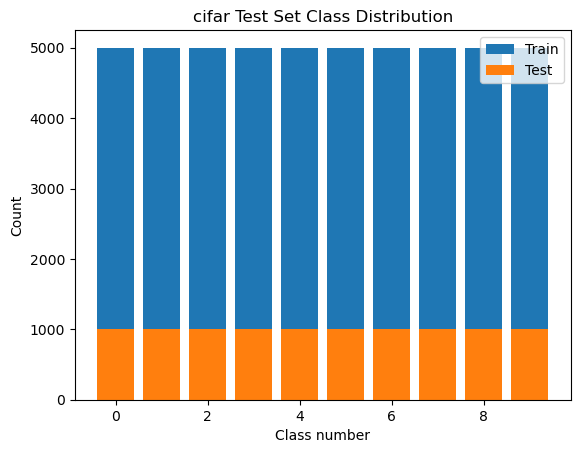

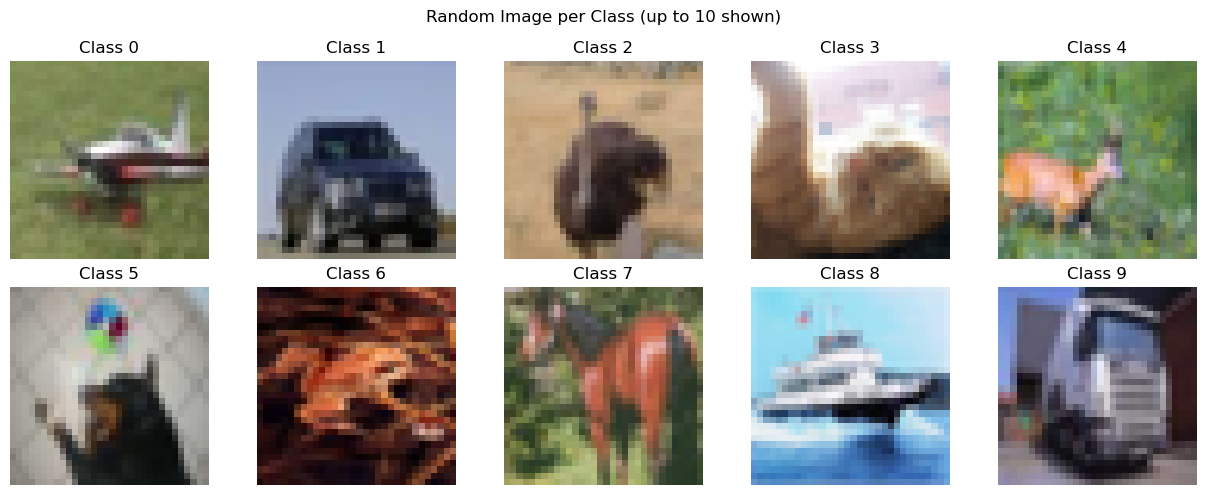

<Figure size 640x480 with 0 Axes>

In [33]:
data_exploration.explore_dataset("cifar")

#### CIFAR-100

CIFAR-100, contains 60,000 32x32 color images across a much larger set of 100 classes, with only 600 images per class. Similar to CIFAR-10, the dataset is split into 50,000 training images and 10,000 test images. However, the classes of CIFAR-100 are much more fine-grained and specific (e.g., multiple types of flowers, multiple species of aquatic animals). Due to the similar nature of many classes, it is harder for the model to get a high accuracy. CIFAR-100 acts as a more challenging classification task for the controller compared to CIFAR-10.





Number of Training Samples: 50000
Number of Test Samples: 10000
Image size: 32
Number of channels: 3
Number of classes:  100


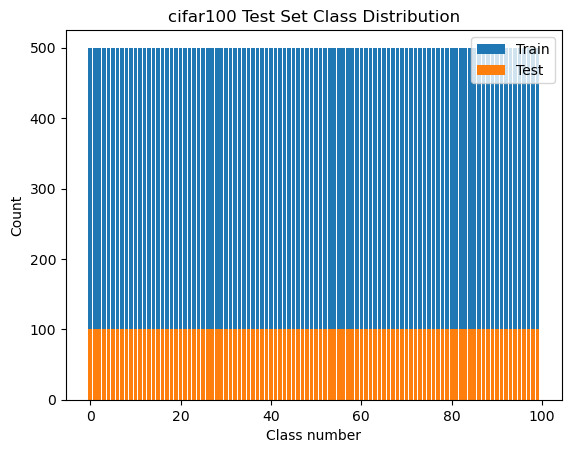

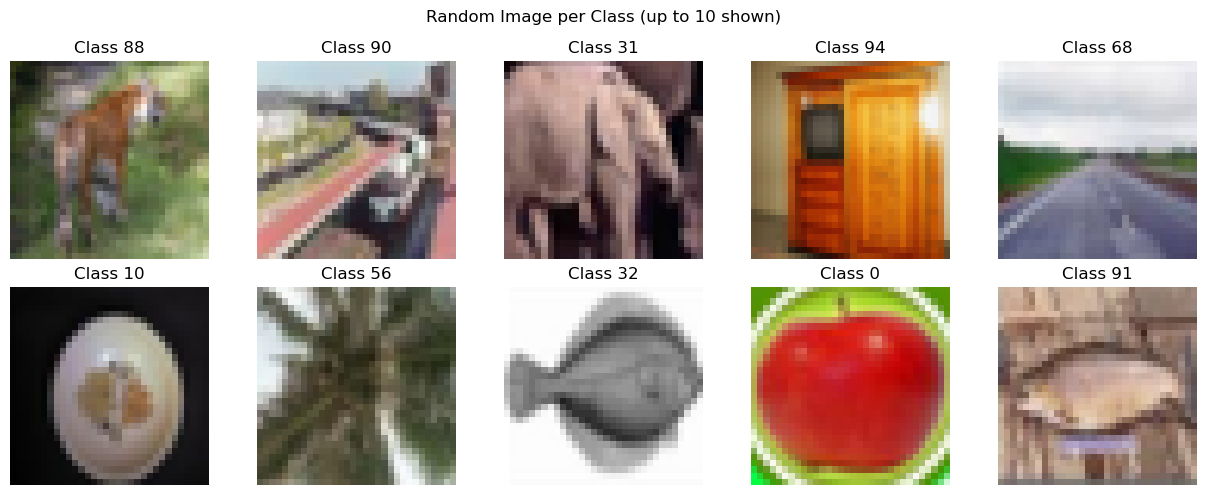

<Figure size 640x480 with 0 Axes>

In [34]:
data_exploration.explore_dataset("cifar100")

### Data Preprocessing

#### Training time
During training of any child model,before submitting a batch of images to the forward pass of the model, we apply some probabilistic augmentation on the images.  These include:
- Reflection padding
- Random cropping
- Random image horizontal flipping <br>

These actions are defined in the class ```Fast_Transform```. It contains code to apply these transformations directly on the image tensors which saves us the computational overhead of converting it into a PIL image and then back. We then perform z-normalization before returning the image. The probabilistic nature of the transformations ensures that every batch is transformed in a unique way and a given batch of images will always have some differences across epochs. This helps the child model be more robust to deformations and other effects which might cause the model to predict the wrong label otherwise
```python
# Reflection padding
img = F.pad(img, pad=[self.padding] * 4, mode='reflect')

top = random.randint(0, img.size(1) - self.crop_size)
left = random.randint(0, img.size(2) - self.crop_size)
# Random crop based on probability
img = img[:, top:top + self.crop_size, left:left + self.crop_size]

# Flipping image based on probability
if random.random() < self.hflip_prob:
    img = torch.flip(img, dims=[2])


mean = self.mean.to(img.device)
std = self.std.to(img.device)
img = (img - mean) / std

return img
```
We also store precomputed values of mean and standard deviation to be used for different datasets in this process as well as dataset specific crop_sizes and padding.

### Comparison of number of learnable parameters on CIFAR-10
| Model                  |  Number of Learnable Parameters |
|:-----------------------|--------------------------------:|
| LeNet                  |                        22834314 |
| VGG_11                 |                          687610 |
| Custom Benchmark_Model |                          492394 |

#### Evaluation time
During evaluation, we apply only z-normalization to the images to ensure consistency and allow for a fair comparison.

Augmentation effect on sample image from CIFAR-10


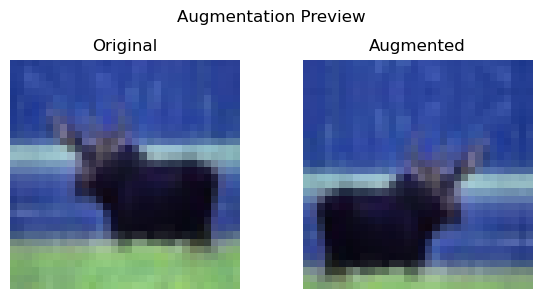

In [22]:
print("Augmentation effect on sample image from CIFAR-10")
data_exploration.get_random_augmented_image("cifar")

### Methodology

#### Common Configurations
- Model Iterations:300
- Number of epochs for training child model: 10
- Controller optimizer: torch.optim.Adam(controller.parameters(), lr=0.001)
- Child model optimizer: torch.optim.Adam(self.model.parameters(), lr=0.001)
- Batch Size: 200

#### Benchmark model
We created small Convolutional Neural Network model encoding to be used and modified by the controller in all our experiments. This is to ensure that the results are comparable and consistent between experiments.
```python
def get_benchmarkModel(input_channels, output_dim):
    return   [
    [
        #Conv(input_channels,output_channels,kernel_size,padding)
        [input_channels, 128, 3, 1],
        [2, 2],
        [128, 64, 3, 1],
        [2, 2]
        [64, 32, 3, 1],
        [2, 2]
    ],
    [
        # FC layers
        [1024, 512],
        [512, 256],
        [256, output_dim]
    ]
]
```
The benchmark model is a 6 layer Convolution Network with 3 Convolutional layers with max pooling and 3 FC layers.





#### Experiment 1 : Can a controller use dataset metadata information to find optimal architectures faster or find better architectures?


In this experiment we want to see the impact of providing dataset-metadata information to our controller.

##### 1.1 Approach

In this experiment we create and train two controllers on the CIFAR 10 dataset. The training loop for both controllers have the same setup. The only difference is that for one of the controllers we make use of the meta layer by passing metadata information `[image_dimension, num_of_classes]` of the dataset to that controller. For the other controller, we pass in `[0, 0]`. Since the meta layer is not initialized with bias this will always ensure that `h_init` and `c_init` for our LSTM default to 0.

##### 1.2 Experiment Setup

First we run the controller without using metadata information
```python
run_experiment(..., use_metadata=False)
```

In [35]:
experiment_name = "EXP_1_CIFAR10_NO_META"

In [15]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=300,
    train_epochs=10,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=2,
    reset_experiment=False,
    use_metadata=False,
)

Image size: 32
Number of channels: 3
Number of classes:  10
Controller will be saved to:  Models\Controller\CNN\EXP_1_CIFAR10_META.pt
Best child model will be saved to:  Models\Child\CNN\EXP_1_CIFAR10_META.pt
Training results will be saved to:  Results\Controller\CNN\EXP_1_CIFAR10_META.csv

[ITER 0] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 64, 3, 0], [2, 2], [64, 256, 3, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.5660010882616043	validation_loss: 0.5642787295579911	test_acc: 0.8099	train_time: 67.91160488128662	policy_gradient: tensor([6.0293], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 16, 3, 2], [2, 2], [16, 128, 1, 0], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.7482884261608124	validation_loss: 0.7389410054683685	test_acc: 0.7433	train_time: 65.77326488494873	policy_gradient: tensor([5.0535], grad_fn=<MulBackward0>)

[ITER 2] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 256, 3, 2], [2, 2], [2

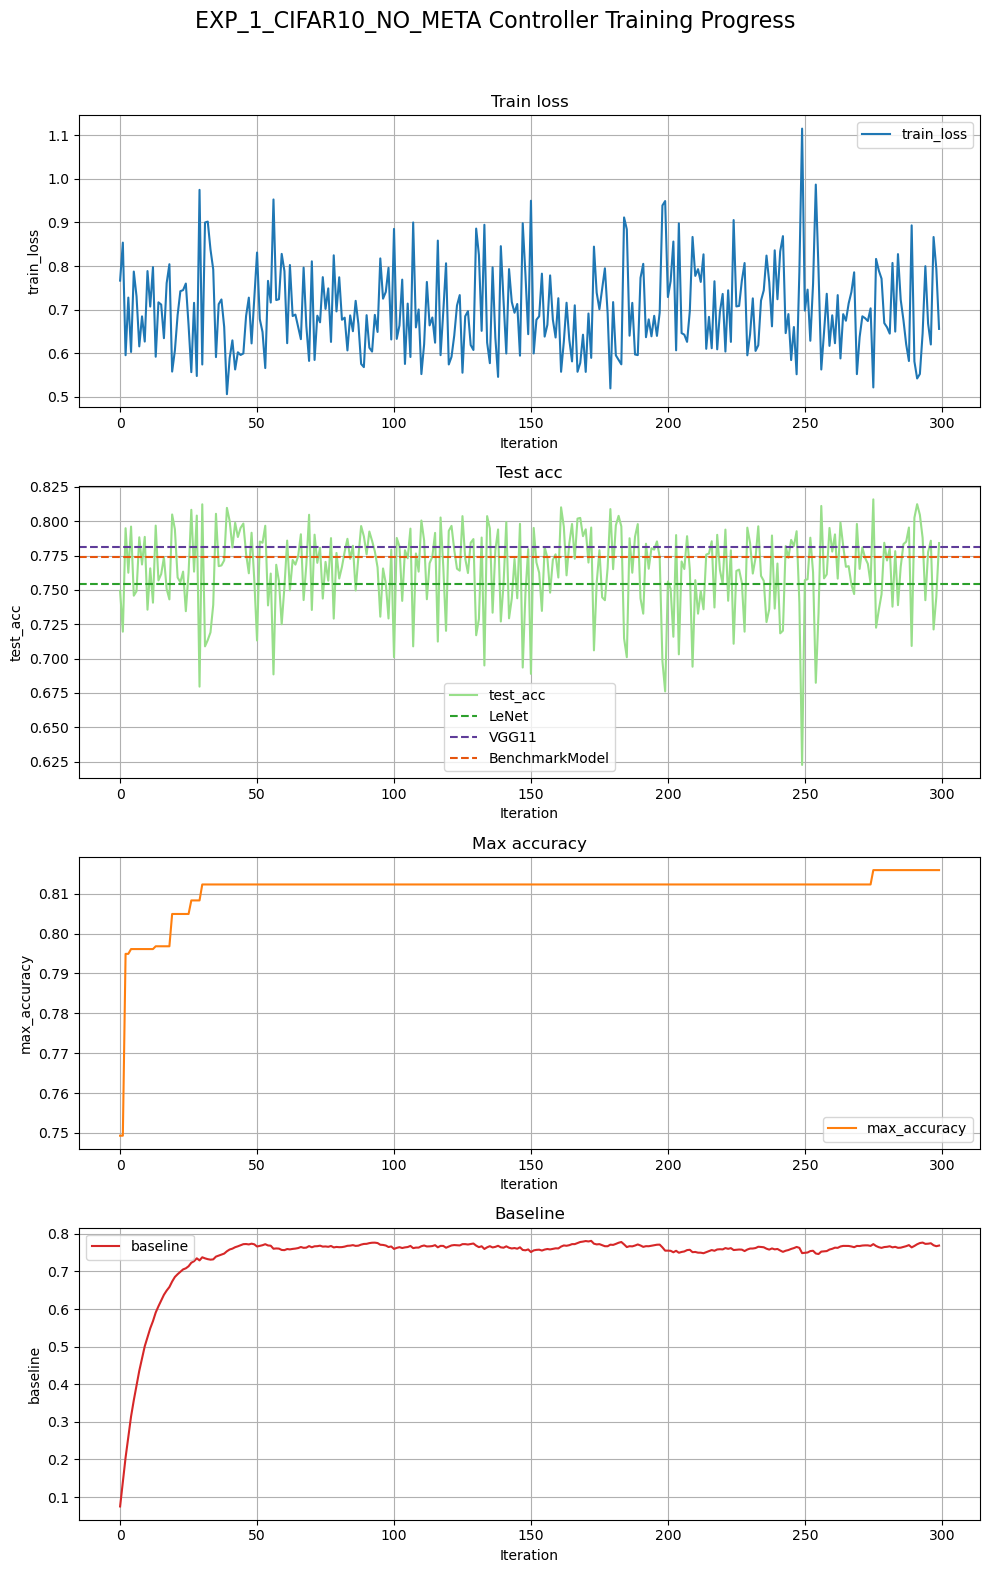

In [36]:
# Plot Training Results
df_exp1_no_meta = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp1_no_meta, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300, colors=colors, references=references_cifar10)

Next we want to run the experiment again but use metadata information
```python
run_experiment(..., use_metadata=True)
```

In [37]:
experiment_name = "EXP_1_CIFAR10_META"

In [13]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=100,
    train_epochs=10,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=2,
    reset_experiment=False,
    use_metadata=True,
)

Image size: 32
Number of channels: 3
Number of classes:  10
Controller will be saved to:  Models\Controller\CNN\EXP_1_CIFAR10_META.pt
Best child model will be saved to:  Models\Child\CNN\EXP_1_CIFAR10_META.pt
Training results will be saved to:  Results\Controller\CNN\EXP_1_CIFAR10_META.csv

[ITER 0] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 256, 3, 1], [2, 2], [256, 128, 1, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.5827026460170746	validation_loss: 0.5951103276014328	test_acc: 0.793	train_time: 73.59025740623474	policy_gradient: tensor([6.1880], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 16, 5, 1], [2, 2], [16, 64, 5, 0], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.9019379184246064	validation_loss: 0.815137243270874	test_acc: 0.7135	train_time: 66.0700192451477	policy_gradient: tensor([4.9547], grad_fn=<MulBackward0>)

[ITER 2] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 128, 5, 1], [2, 2], [128

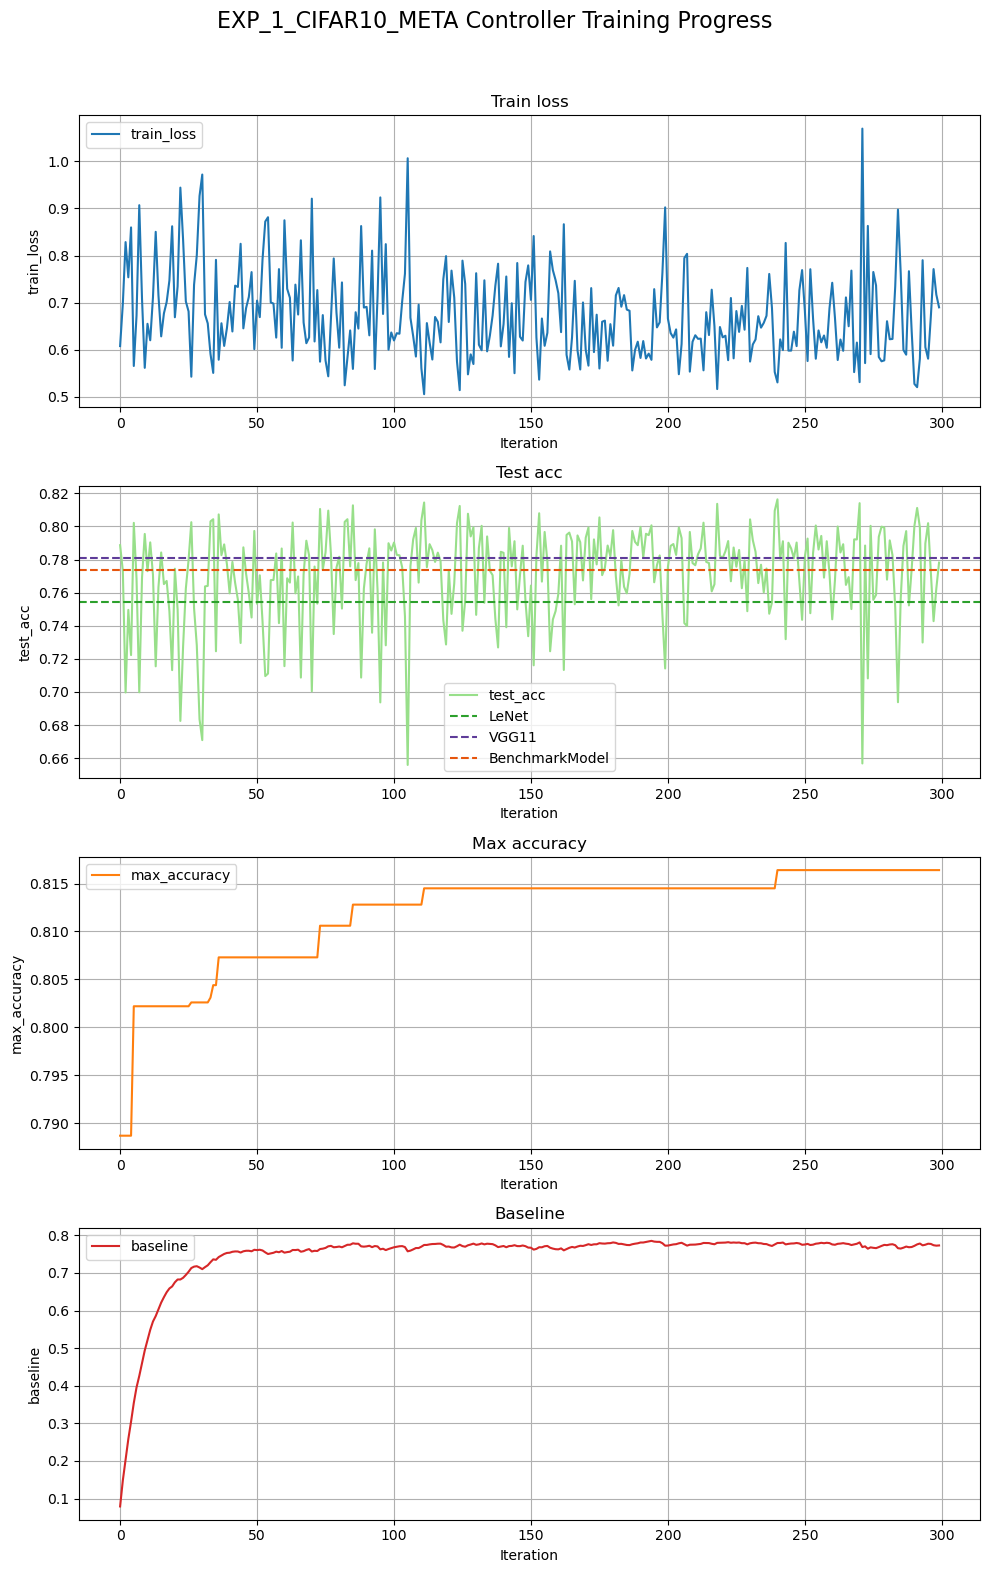

In [38]:
df_exp1_meta = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp1_meta, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300, colors=colors, references=references_cifar10)

##### 1.3. Comparison

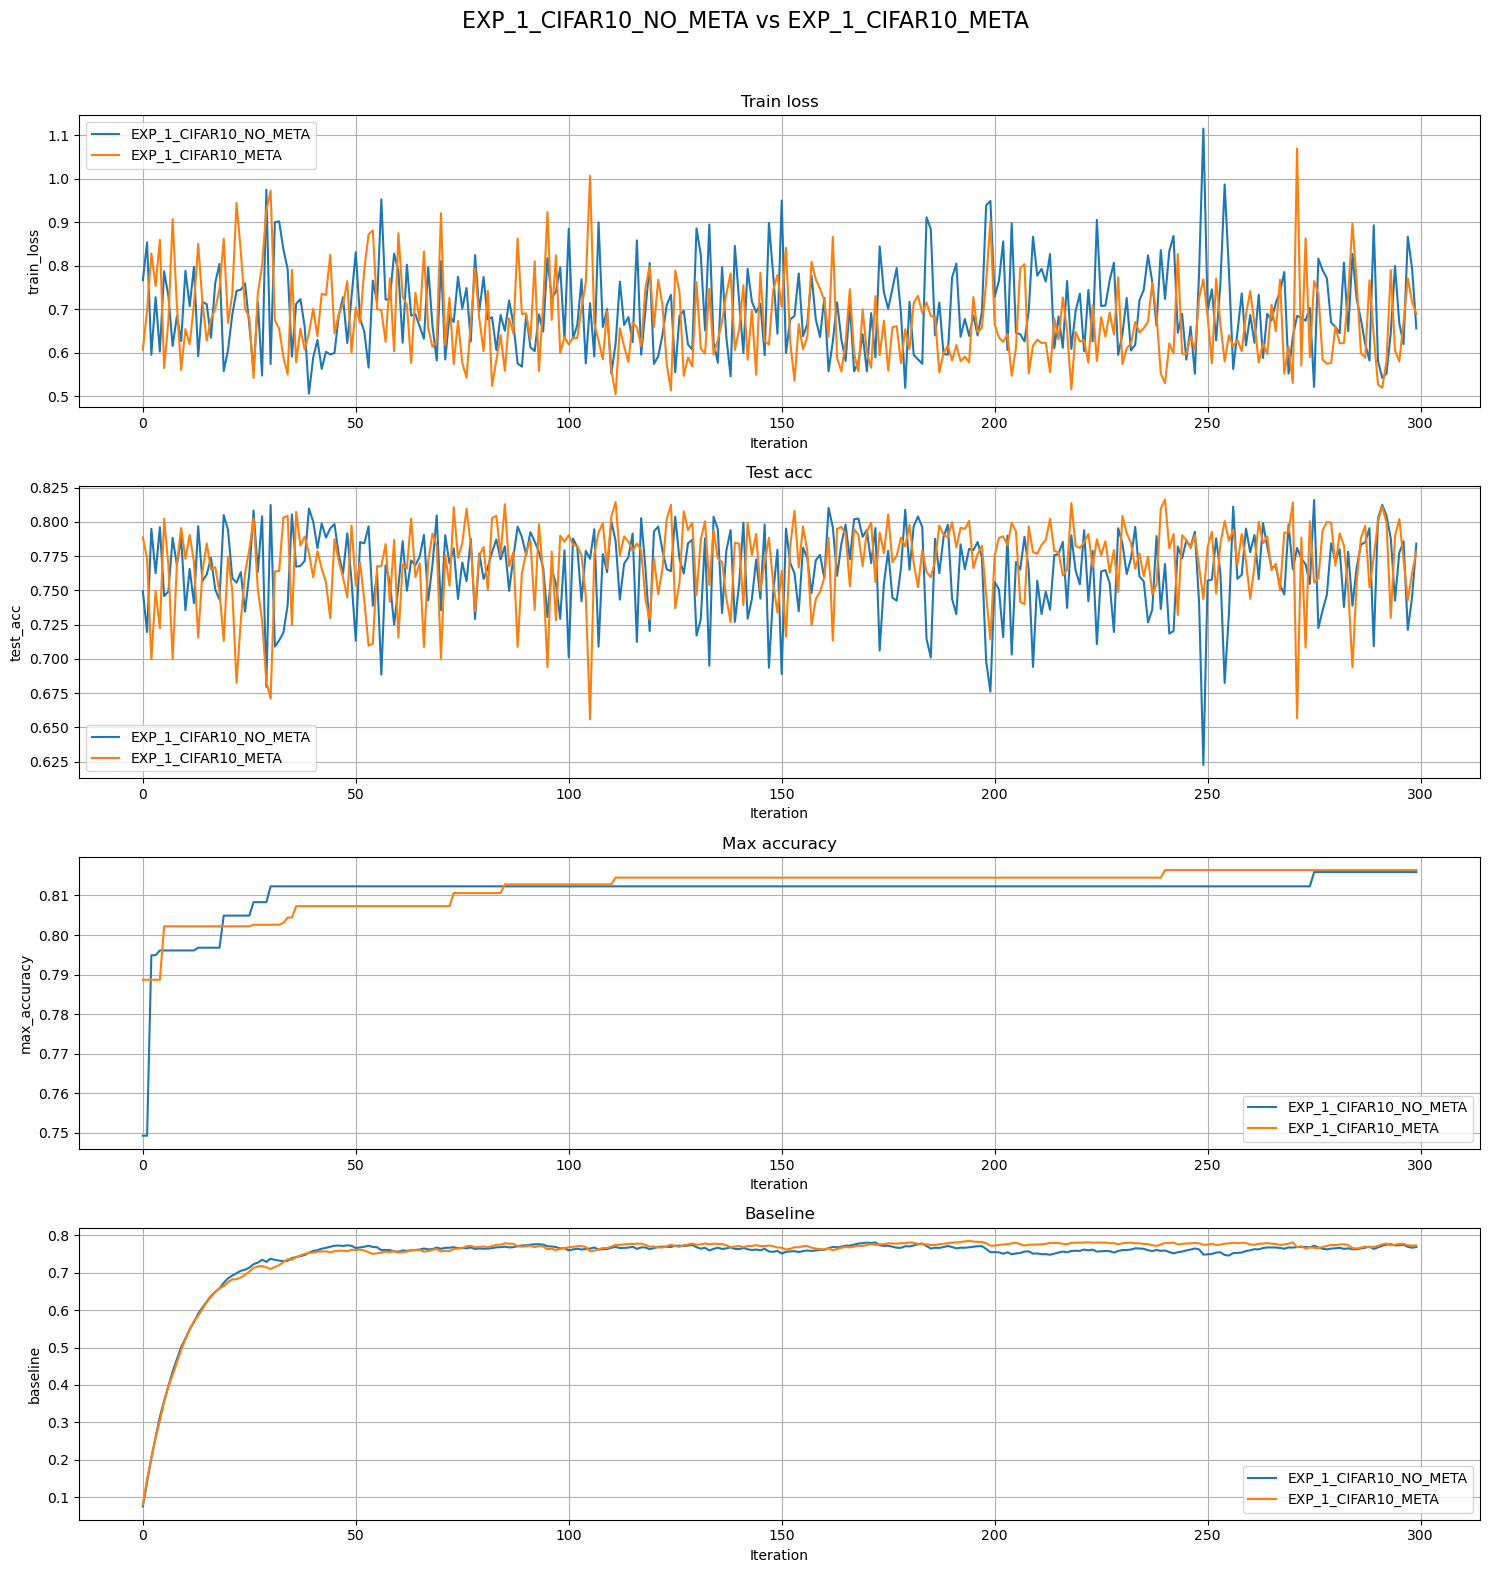

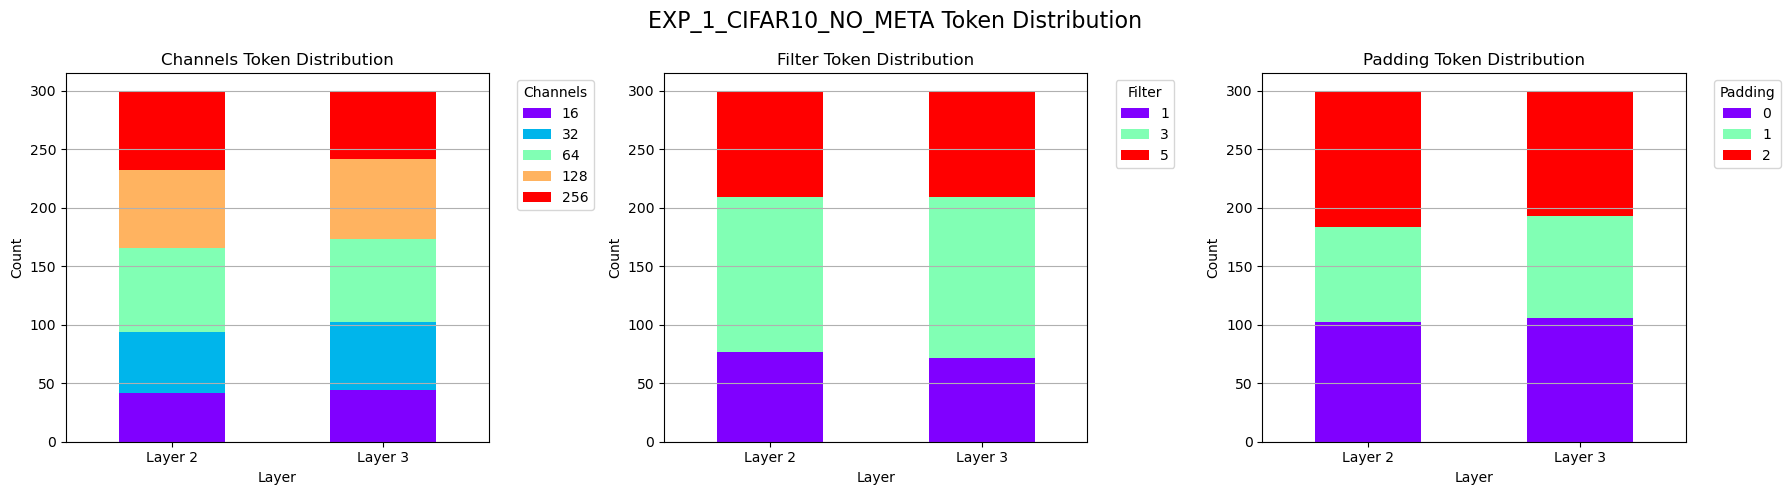

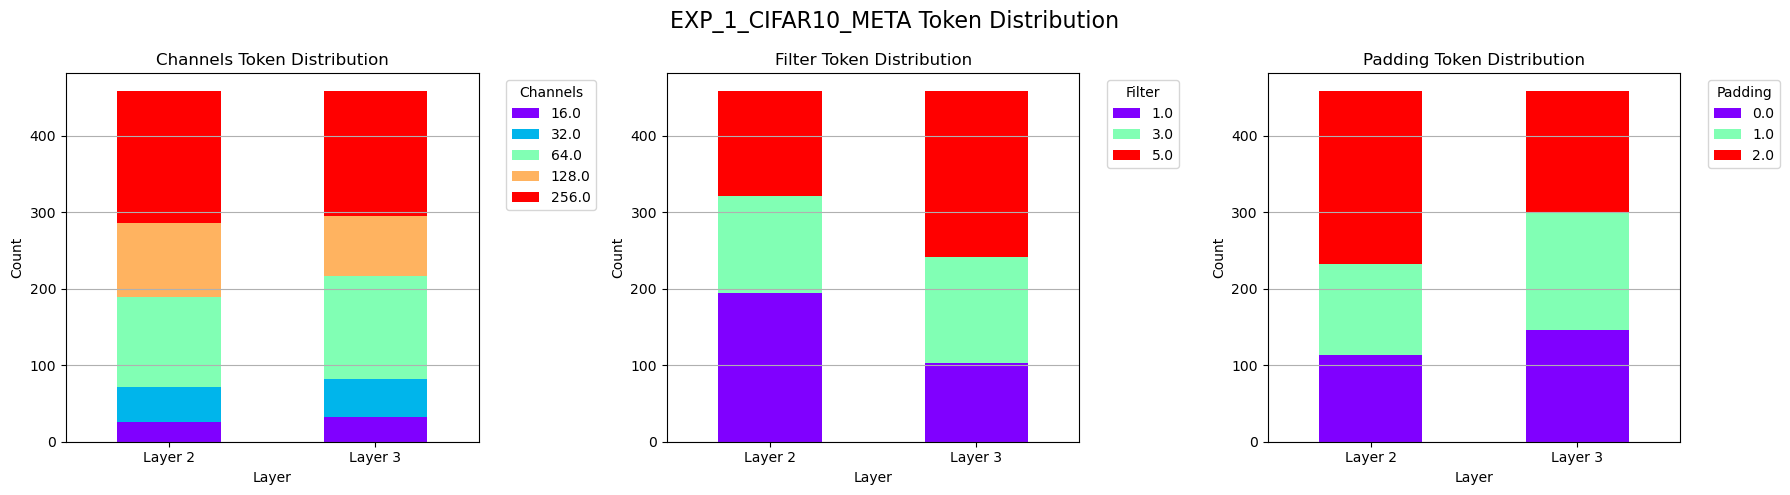

In [39]:
analysis.compare_metrics([df_exp1_no_meta, df_exp1_meta], df_names=["EXP_1_CIFAR10_NO_META", "EXP_1_CIFAR10_META"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300)

analysis.plot_token_distribution(df_exp1_no_meta, "EXP_1_CIFAR10_NO_META", include_layer1=False, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp1_meta, "EXP_1_CIFAR10_META", include_layer1=False, use_sns=True, sns_palette="rainbow")

In [40]:
print("EXP_1_CIFAR10_NO_META Statistics:")
analysis.compute_stats(df_exp1_no_meta, metrics=["test_acc", "baseline"], stats=["mean", "std", "max"], limit=300)

EXP_1_CIFAR10_NO_META Statistics:


test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.767600  0.029862  0.8123  0.628622  0.179737  0.773777
50-99        0.765590  0.023858  0.8047  0.766626  0.004834  0.776498
100-149      0.764118  0.031471  0.8037  0.765526  0.004078  0.774249
150-199      0.767404  0.032539  0.8101  0.768001  0.007239  0.781275
200-249      0.755822  0.032796  0.7963  0.756999  0.004590  0.765588
250-299      0.768104  0.027678  0.8159  0.764481  0.007289  0.776719

In [41]:
print("EXP_1_CIFAR10_META Statistics:")
analysis.compute_stats(df_exp1_meta, metrics=["test_acc", "baseline"], stats=["mean", "std", "max"], limit=300)

EXP_1_CIFAR10_META Statistics:


test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.758784  0.033926  0.8073  0.621680  0.176569  0.761689
50-99        0.765034  0.030604  0.8128  0.764267  0.007318  0.778921
100-149      0.772240  0.028459  0.8145  0.771950  0.004606  0.778571
150-199      0.774952  0.023871  0.8080  0.774031  0.006710  0.785464
200-249      0.778472  0.018890  0.8164  0.778043  0.002480  0.781922
250-299      0.773830  0.030198  0.8141  0.774154  0.004468  0.781378

##### 1.4. Analysis

The train loss for both settings fluctuates similarly, though the META controller shows slightly more stable loss patterns over iterations. In terms of test accuracy, the META controller generally maintains higher accuracy with less severe drops compared to the NO_META variant, suggesting improved sample quality. This is further confirmed by the tabulated statistics where we can observe that the META controller maintain higher average test accuracy (~76-77%) and lower variance (from 0.03-0.01). The max accuracy curve shows that while both controllers do learn to improve over time, the META controller reaches comparable or slightly better maximum performance more consistently. Finally, the baseline values converge similarly, but the META variant appears to stabilize faster. Overall, meta-conditioning provides a mild but consistent advantage in controller performance

The token distributions reveal key differences between the NO_META and META controllers. In the NO_META setting, the controller shows a relatively balanced selection across channel sizes, filter sizes, and paddings, but with a slight bias toward mid-sized choices (e.g., 64 channels, 3×3 filters). In contrast, the META controller displays a stronger preference for larger architectures: 256 channels, 5×5 filters, and higher paddings are sampled more frequently. This suggests that with access to dataset metadata, the controller adapts its sampling strategy toward more complex models, likely to better fit the data characteristics and improve final task performance.

#### Experiment 2 : Can a NAS Controller Design Better Models When Allowed to Generate All Convolution Layers?

##### 2.1. Approach

In our previous experiment we had trained the controller to generate 2 layers and were using them to replace the intermediate and final convolution layer of the model. We wanted to study the effect of letting the controller generate 3 layers and use that to replace all 3 convolution layers of the model. This gives the model more freedom in terms of hyperparameter combinations but it also increases the search space considerably. With 2 layers to generate, the search space was 45<sup>2</sup> = 2025 possible combinations, with 3 however, this increases to 45<sup>3</sup> = 91125, even with our limited vocabulary. We expect to see greater variance in child model test accuracy, however, the more interesting aspect would be to see if the model can produce model architectures which achieve comparable test accuracy as compared to our benchmark model and the best NAS model produced with 2 layer generation.

##### 2.2. Experiment setup

We modify the experiment run parameters to force the controller to generate 3 layers and insert into the corresponding 3 layers of the base model. <br>
Dataset used: CIFAR-10

In [42]:
experiment_name = "EXP_2_3_Layer_CIFAR_10"

In [18]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=300,
    train_epochs=10,
    positions=[0,1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=3,
    reset_experiment=True,
    use_metadata=True,
)

Image size: 32
Number of channels: 3
Number of classes:  10
Controller will be saved to:  Models\Controller\CNN\EXP_2_3_Layer_CIFAR_10.pt
Best child model will be saved to:  Models\Child\CNN\EXP_2_3_Layer_CIFAR_10.pt
Training results will be saved to:  Results\Controller\CNN\EXP_2_3_Layer_CIFAR_10.csv

[ITER 0] Model encoding = [[[3, 32, 1, 2], [2, 2], [32, 16, 1, 2], [2, 2], [16, 16, 5, 2], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 1.1718916654586793	validation_loss: 1.1155265200138091	test_acc: 0.6	train_time: 61.774282455444336	policy_gradient: tensor([6.8127], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 256, 1, 1], [2, 2], [256, 32, 3, 0], [2, 2], [32, 16, 5, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 1.1638029904365539	validation_loss: 1.1259577369689941	test_acc: 0.5936	train_time: 75.75865983963013	policy_gradient: tensor([5.9679], grad_fn=<MulBackward0>)

[ITER 2] Model encoding = [[[3, 128, 3, 0], [2, 2], [128, 16, 5, 0], [2, 2

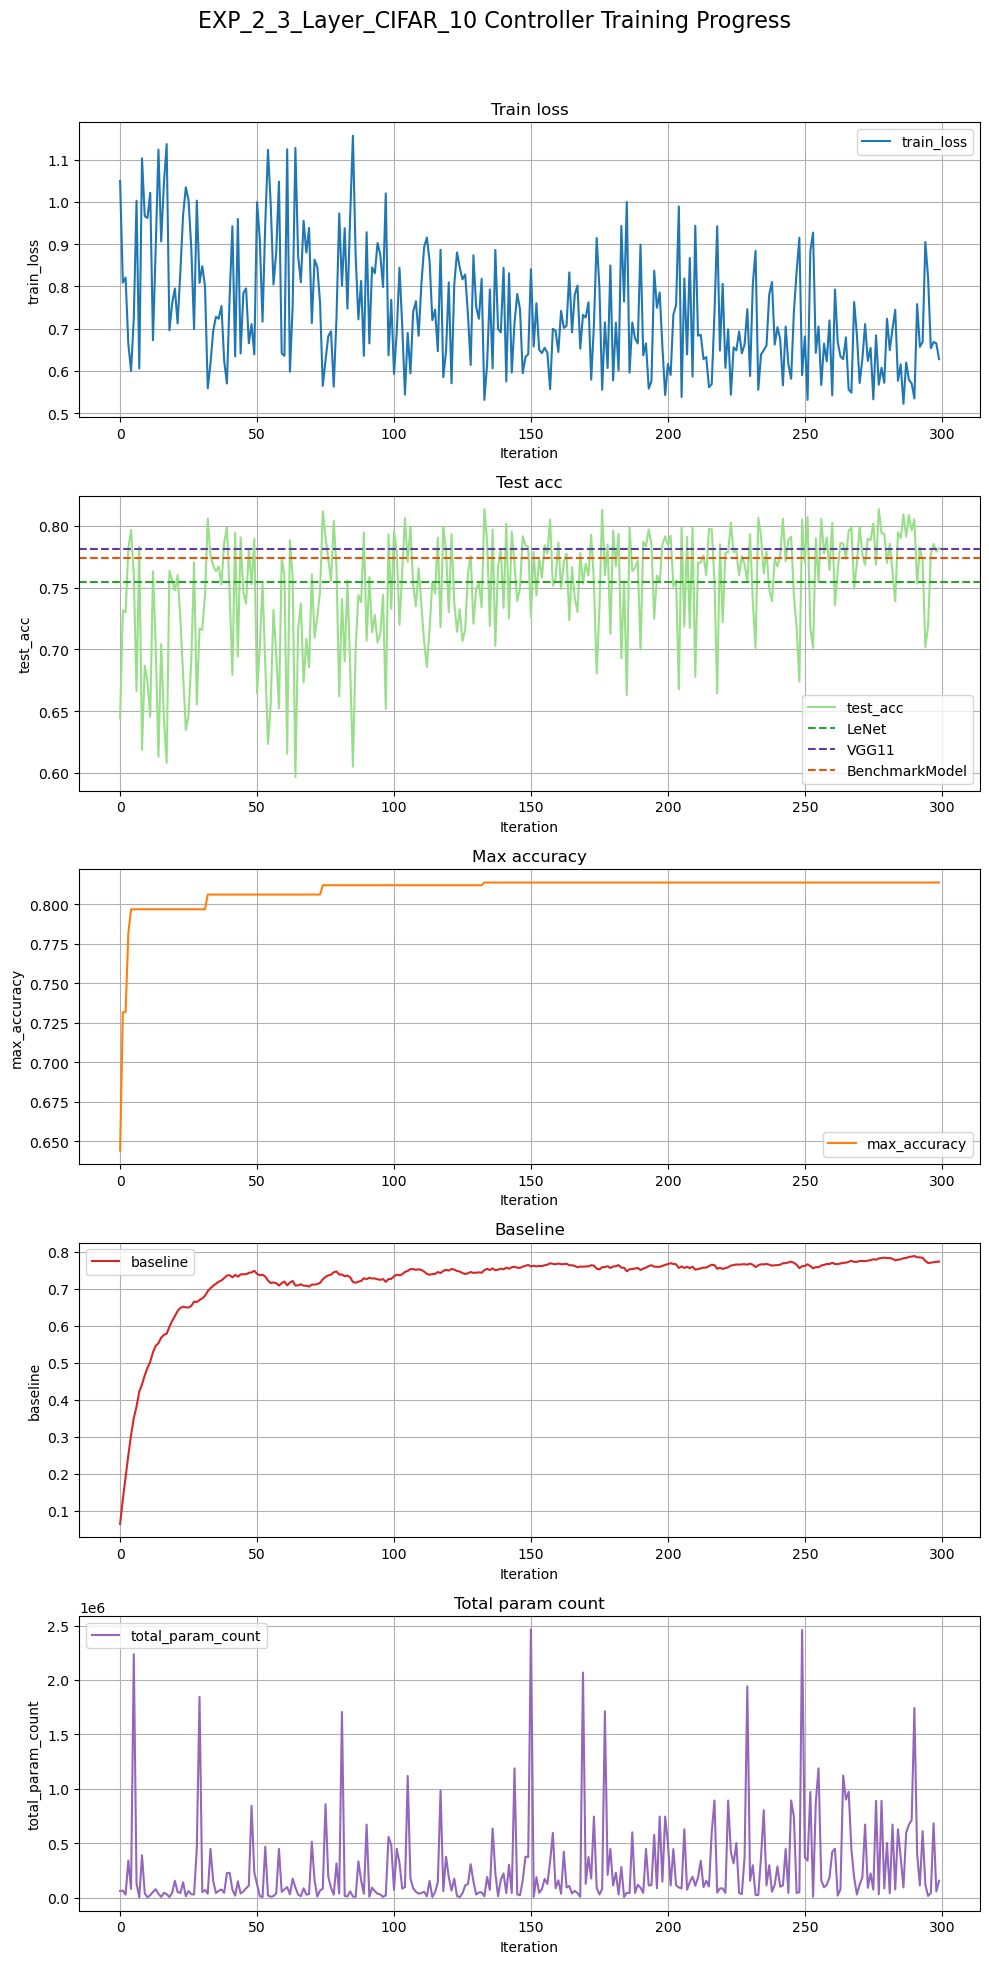

In [43]:
df_exp2 = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp2, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300, colors=colors, references=references_cifar10) #Add benchmark

##### 2.3. Now lets compare the results of the 3 layer controller model vs the previous experiment's 2 layer controller model

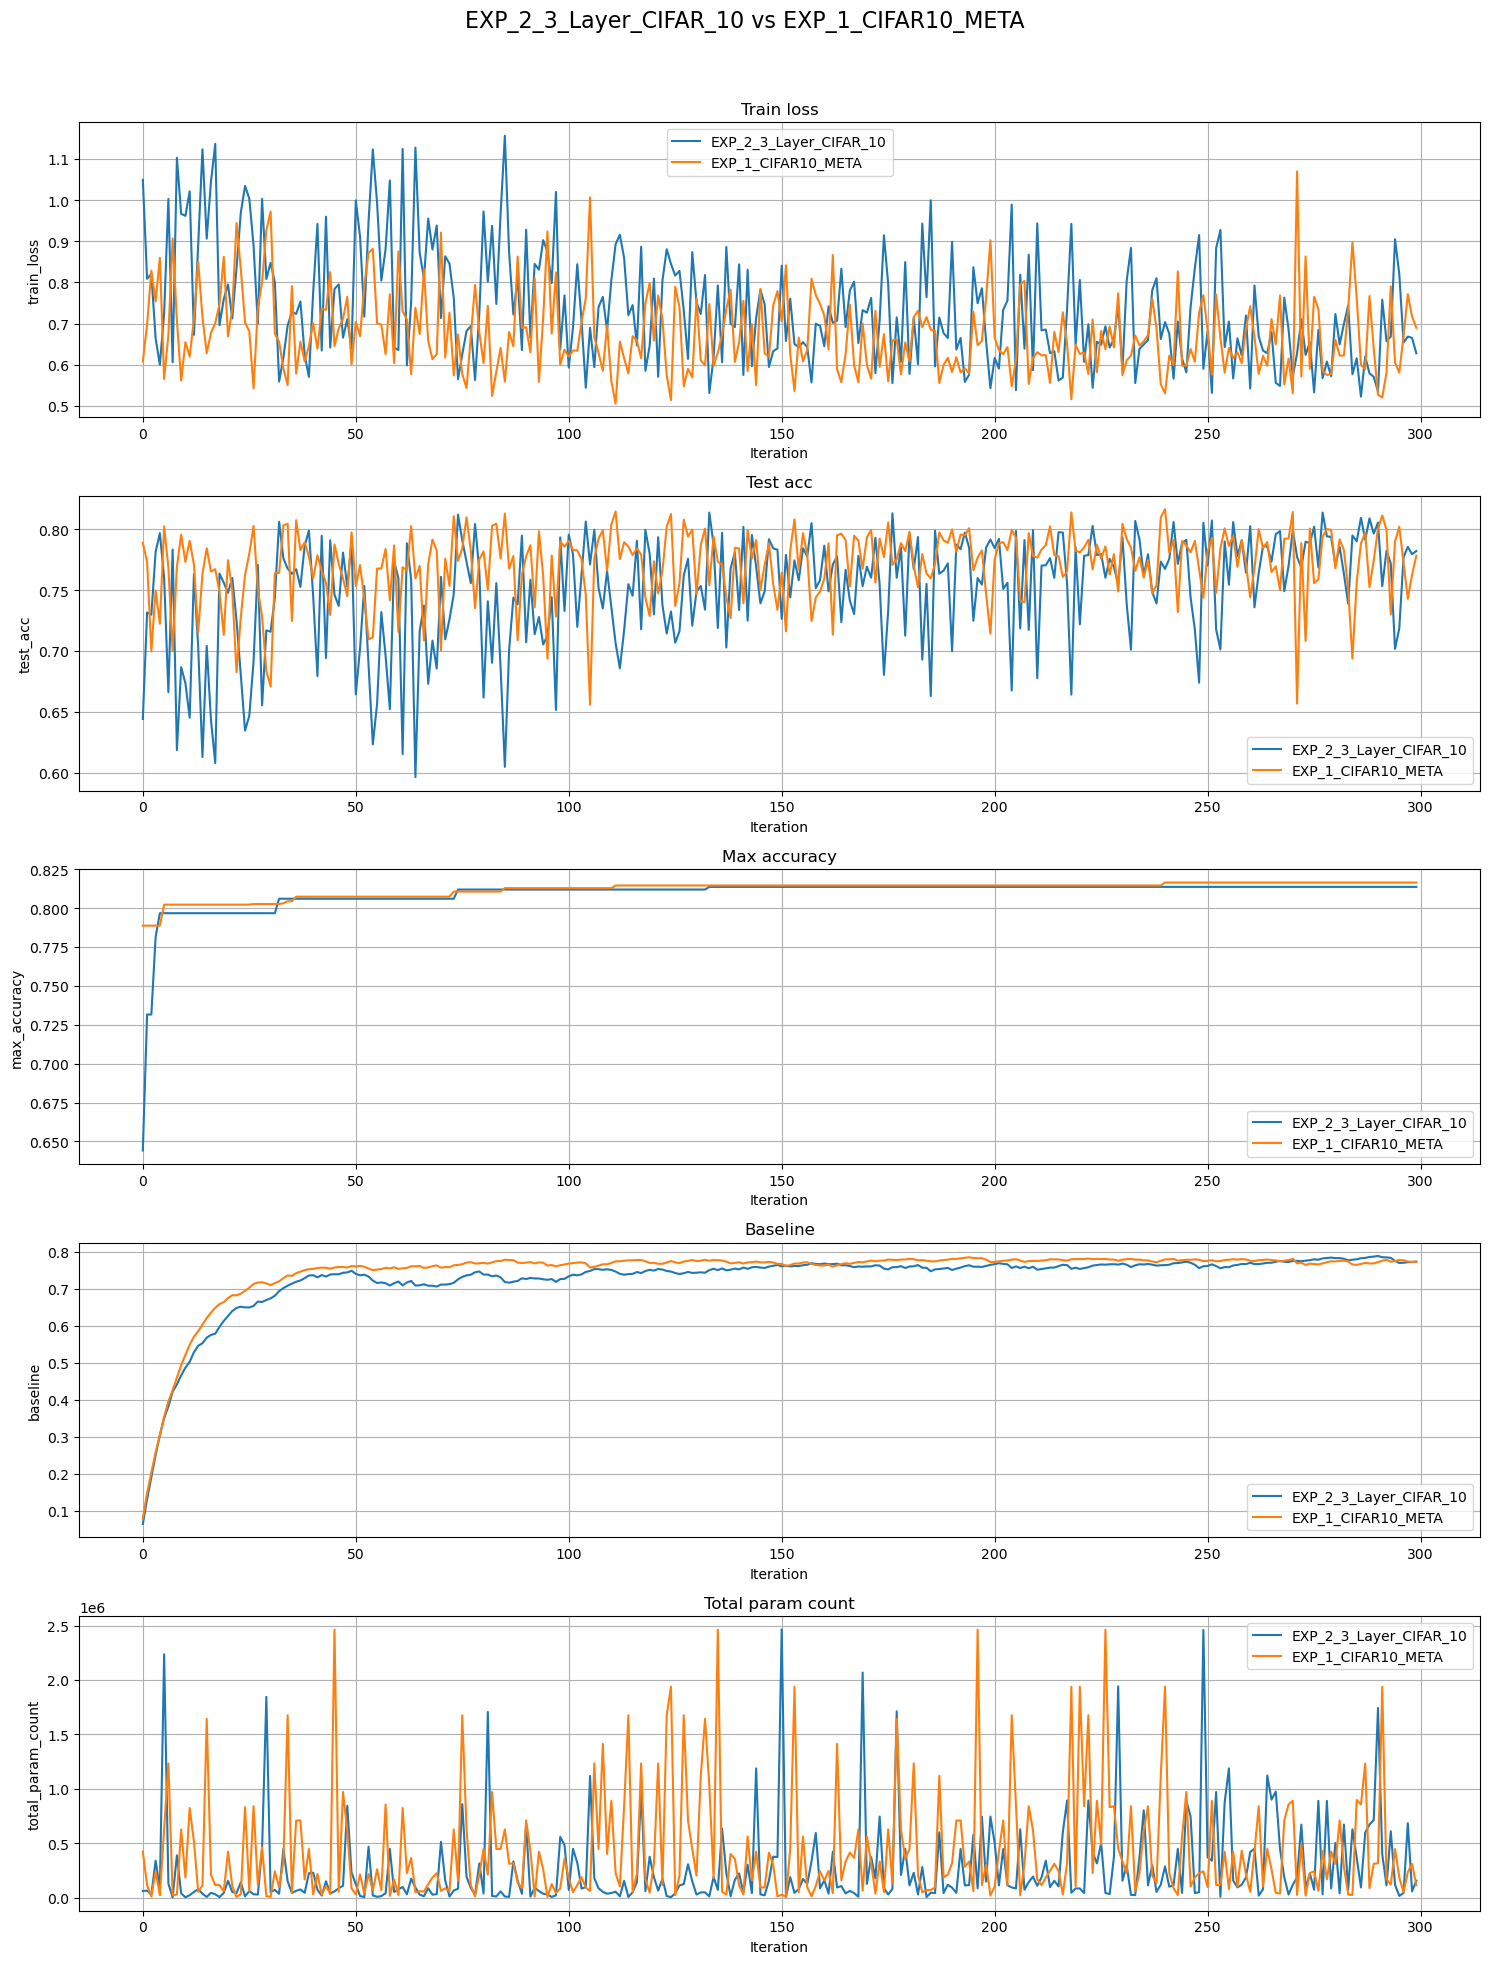

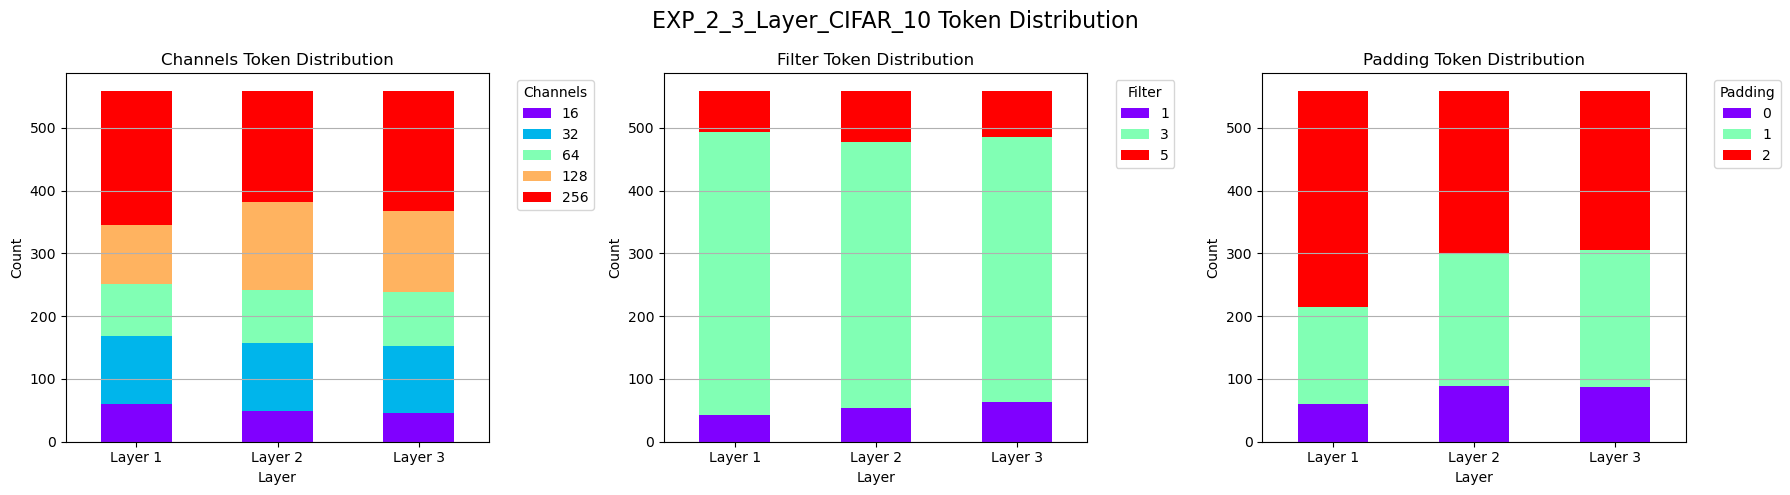

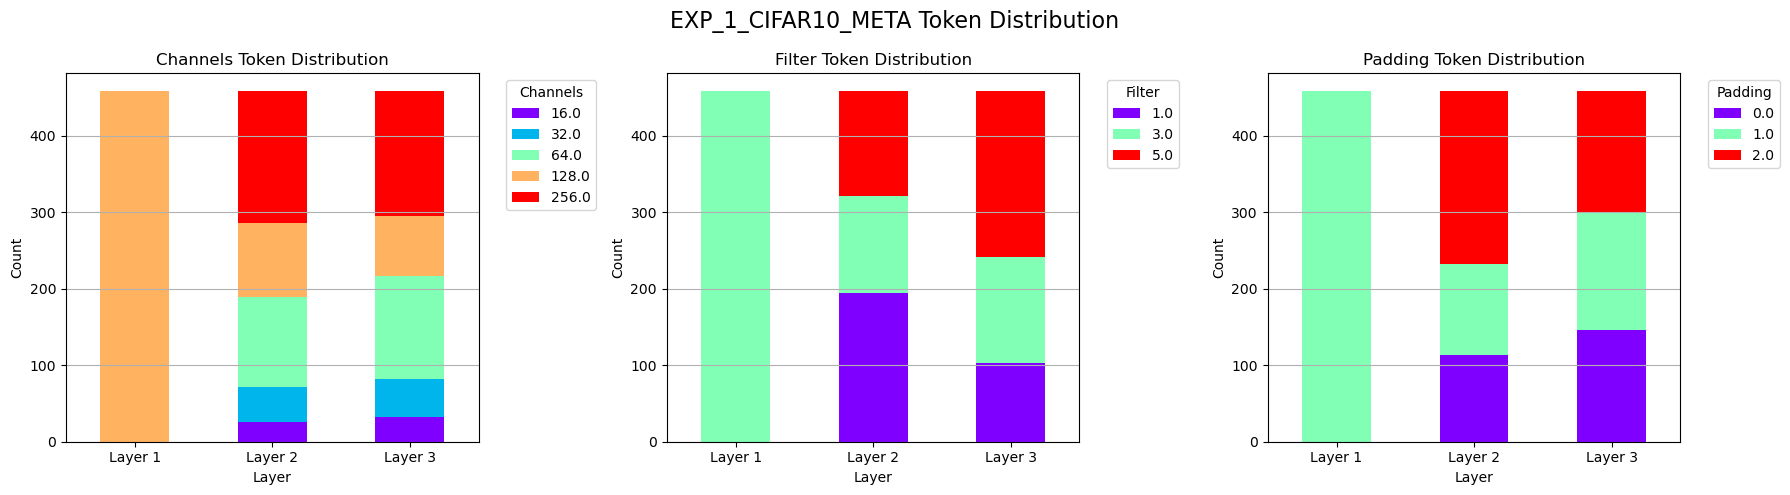

In [44]:
analysis.compare_metrics([df_exp2, df_exp1_meta], df_names=["EXP_2_3_Layer_CIFAR_10", "EXP_1_CIFAR10_META"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300)

analysis.plot_token_distribution(df_exp2, "EXP_2_3_Layer_CIFAR_10", include_layer1=True, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp1_meta, "EXP_1_CIFAR10_META", include_layer1=True, use_sns=True, sns_palette="rainbow")

##### 2.4. Token distribution Analysis

Comparing the token distributions between the two experiments reveals how the degree of control impacts the controller’s design strategy. In the 3-layer generation setup (EXP_5), the controller explores a wider range of filter sizes across all layers, choosing more evenly between small (16, 32) and large (128, 256) channel sizes. In contrast, in the 2-layer generation setup (EXP_1), the first layer remains fixed, leading to a strong bias towards larger filters (mostly 256) in the generated layers as the controller attempts to compensate for the frozen initial representation.

For kernel size selection, the 3-layer controller overwhelmingly favors 3x3 kernels at all layers,which seems to align with traditional CNN design choices. Meanwhile, the 2-layer controller, while still favoring 3x3 kernels overall, demonstrates a more balanced use of 1x1 and 5x5 kernels in deeper layers.

Padding choices further show this difference: the 3-layer controller consistently prefers padding values of 1 and 2 to preserve spatial dimensions across all layers, whereas the 2-layer controller exhibits a more varied padding strategy, occasionally allowing dimension shrinkage in later layers.



In [45]:
print("EXP_2_3_Layer_CIFAR_10 Statistics:")
analysis.compute_stats(df_exp2, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"], limit=300)

EXP_2_3_Layer_CIFAR_10 Statistics:


test_acc                   total_param_count                          
                 mean       std     max              mean            std        max
range_label                                                                        
0-49         0.725768  0.056130  0.8060         190565.12  412021.821399  2235904.0
50-99        0.719806  0.052323  0.8119         169696.32  296447.137137  1705472.0
100-149      0.755684  0.033020  0.8136         194474.88  267130.416934  1187328.0
150-199      0.760638  0.032259  0.8130         314302.08  502289.003786  2465152.0
200-249      0.762042  0.037152  0.8067         341211.52  461909.081556  2459008.0
250-299      0.776780  0.026854  0.8136         409273.28  391523.202790  1742528.0

In [46]:
print("EXP_1_CIFAR10_META Statistics:")
analysis.compute_stats(df_exp1_meta, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"],limit=300)

EXP_1_CIFAR10_META Statistics:


test_acc                   total_param_count                          
                 mean       std     max              mean            std        max
range_label                                                                        
0-49         0.758784  0.033926  0.8073         381875.52  505488.499328  2461696.0
50-99        0.765034  0.030604  0.8128         282540.80  315669.890530  1675264.0
100-149      0.772240  0.028459  0.8145         552388.48  617076.801951  2461696.0
150-199      0.774952  0.023871  0.8080         419198.08  519226.033403  2461696.0
200-249      0.778472  0.018890  0.8164         582030.72  592173.660114  2461696.0
250-299      0.773830  0.030198  0.8141         364602.88  373854.084362  1937408.0

##### 2.5. Result Analysis

Comparing the results of the previous experiment (Experiment 1), where the controller generated only 2 layers, with the current experiment where it generates all 3 layers, we observe some interesting trends.

Initially, the 3-layer controller produced child models with a slightly lower mean test accuracy compared to the 2-layer controller (0.72 vs 0.75) in the first 50 iterations. While the 2-layer controller’s mean test accuracy rose to 0.76 in the next 50 iterations, the 3-layer controller’s accuracy dipped further to 0.719. However, by the end of 300 iterations, both controllers achieved comparable accuracies around 0.77, indicating a positive convergence trend for both models.

It is notable that the 2-layer controller reached this stability point much faster, suggesting that a smaller search space enables more efficient learning. In terms of accuracy variance, the 3-layer controller’s child models initially exhibited higher standard deviation, as expected given the larger search space. However, in the final 50 models, the 3-layer controller slightly outperformed the 2-layer controller in variance, indicating eventual stabilization.

Regarding model complexity, the 3-layer controller initially generated models with lower mean parameter counts. However, as the search progressed — and given that accuracy was the sole optimization target — the generated models became increasingly complex, ultimately surpassing the 2-layer controller’s models in parameter count.

One important observation is that the total parameter count for the 3-layer models includes all three convolutional layers, whereas the 2-layer controller’s child models retained a fixed first layer. This likely explains the initially lower parameter counts for the 3-layer controller, as it had the freedom to select smaller filter sizes even in the first convolutional layer.

#### Experiment 3 : Can we modify the reward function to optimize for both accuracy and model efficiency?

In this experiment, we modify the reward function in the RL loop to balance test accuracy with model complexity. The goal is to guide the controller toward architectures that are both accurate and efficient (uses fewer parameters).

##### 3.1. Approach

The reward function is changed to the following:

```
w1 = 1
w2 = 0.05
reward = w1 * accuracy - w2 * log(num_parameters)
```

Since the parameter count will be very high (~in the range of millions), we use log operation to scale down the values. The complexity is then applied as a penalty to the reward with a weight factor `w2`.

##### 3.2. Experiment Setup

In [47]:
experiment_name = "EXP_3_CIFAR10"

In [20]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=5,
    train_epochs=10,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_with_model_complexity_reward,
    max_child_layers=2,
    reset_experiment=False,
    use_metadata=False,
)

Image size: 32
Number of channels: 3
Number of classes:  10
Controller will be saved to:  Models\Controller\CNN\EXP_3_CIFAR10.pt
Best child model will be saved to:  Models\Child\CNN\EXP_3_CIFAR10.pt
Training results will be saved to:  Results\Controller\CNN\EXP_3_CIFAR10.csv

[ITER 0] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 32, 3, 0], [2, 2], [32, 32, 5, 0], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.9356866099834442	validation_loss: 0.8776491045951843	test_acc: 0.6937	train_time: 65.38376927375793	policy_gradient: tensor([0.5981], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 32, 1, 1], [2, 2], [32, 16, 1, 2], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 0.9526367859840393	validation_loss: 0.8833580660820007	test_acc: 0.6857	train_time: 65.24522709846497	policy_gradient: tensor([0.2253], grad_fn=<MulBackward0>)

[ITER 2] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 64, 3, 1], [2, 2], [64, 64, 1, 0], [2, 

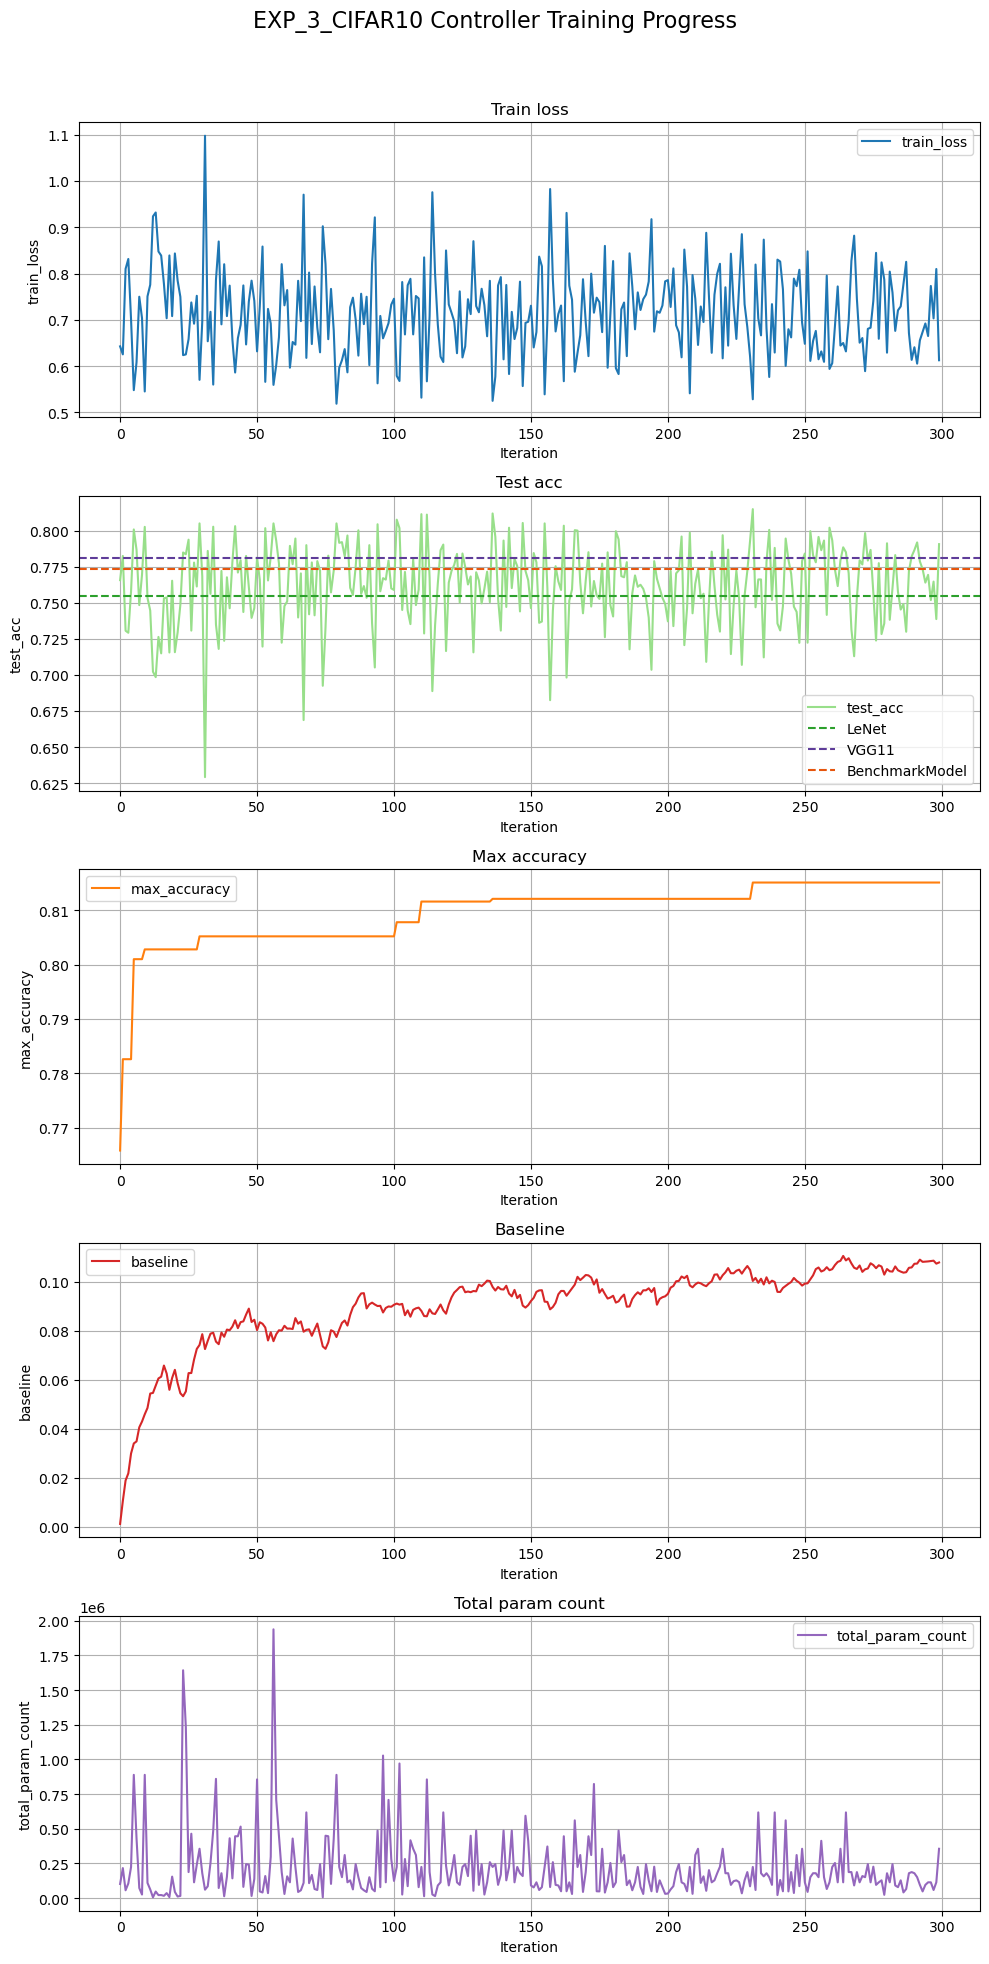

In [48]:
df_exp3 = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp3, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300, colors=colors, references=references_cifar10)

##### 3.3. Comparison with the META controller from Experiment 1

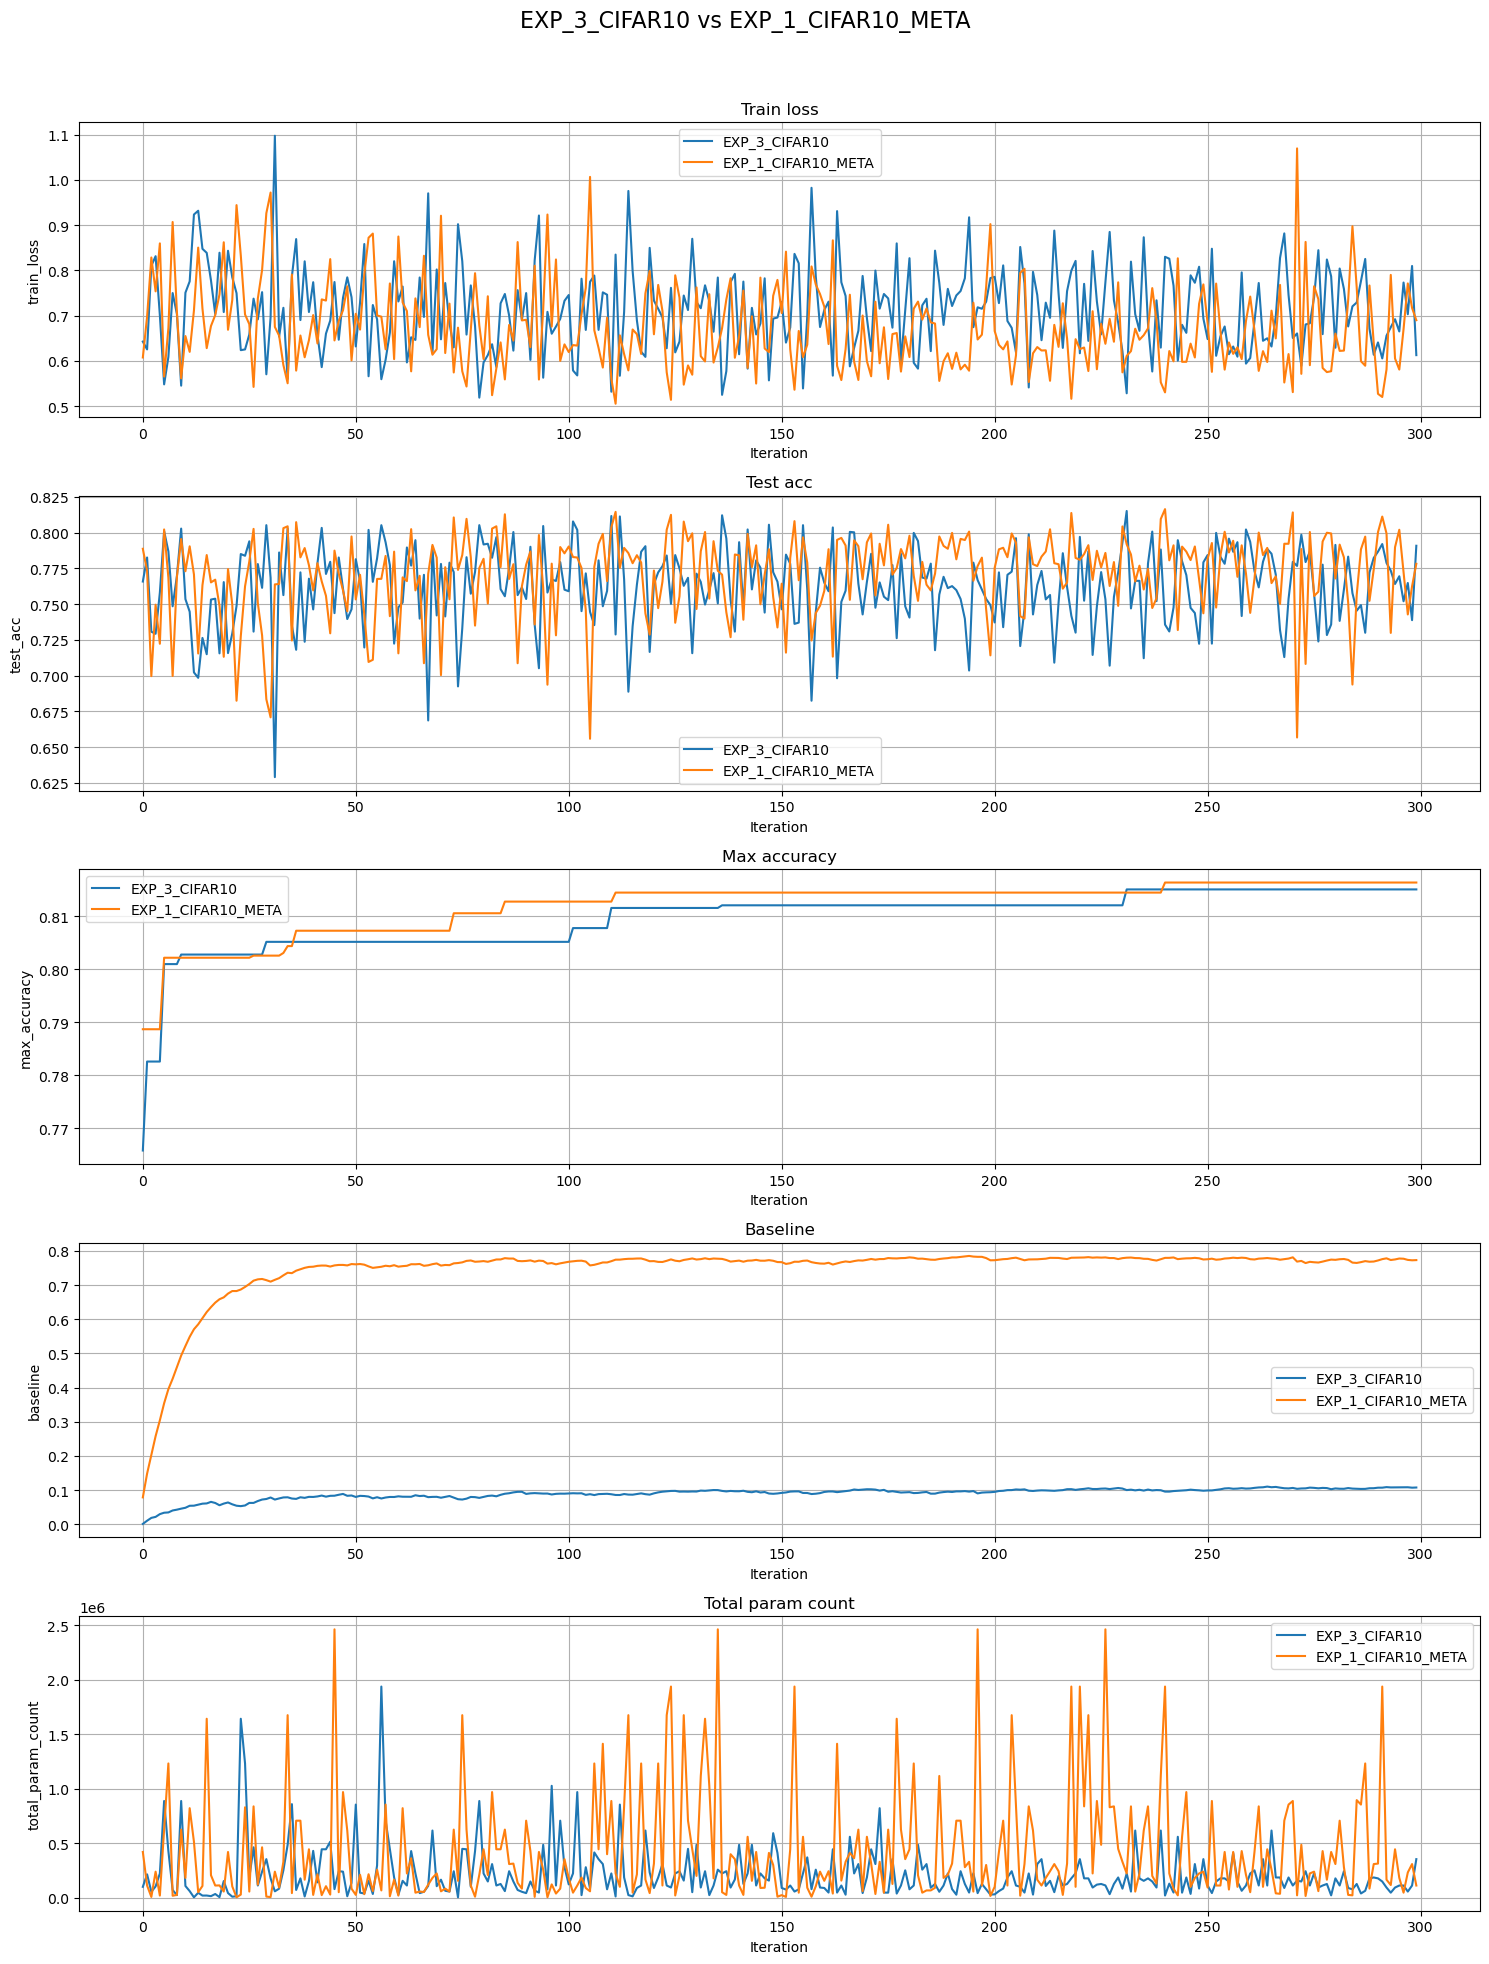

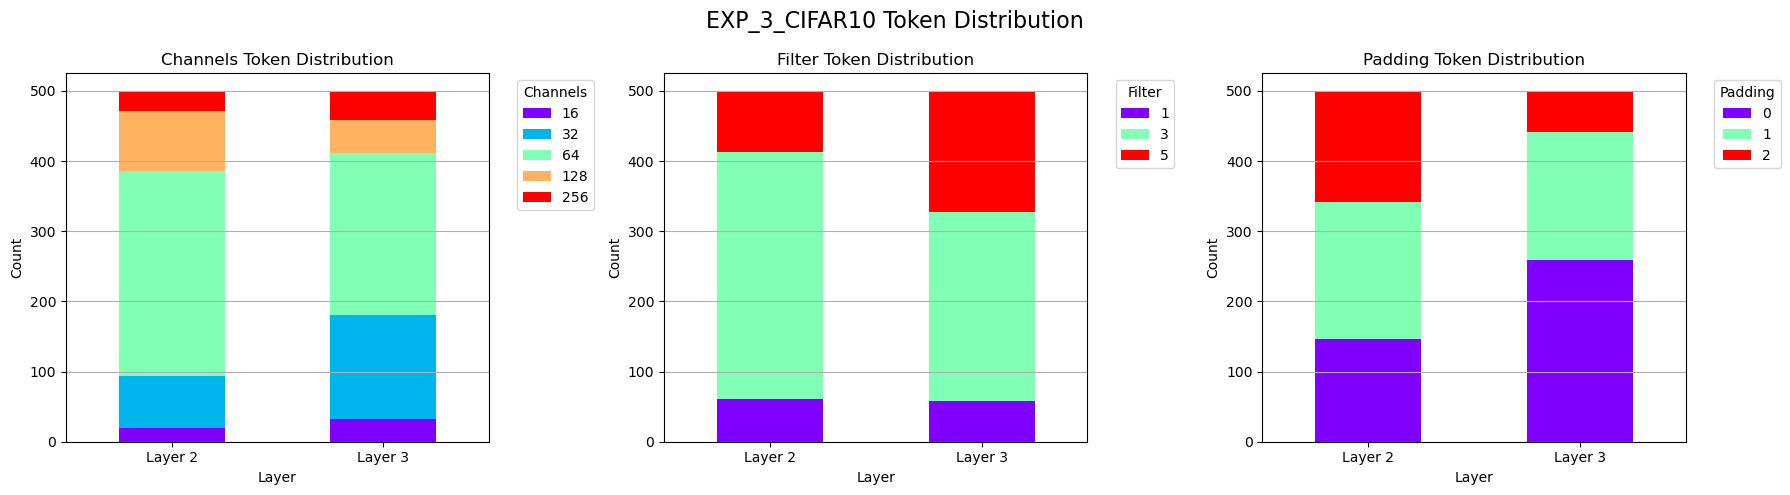

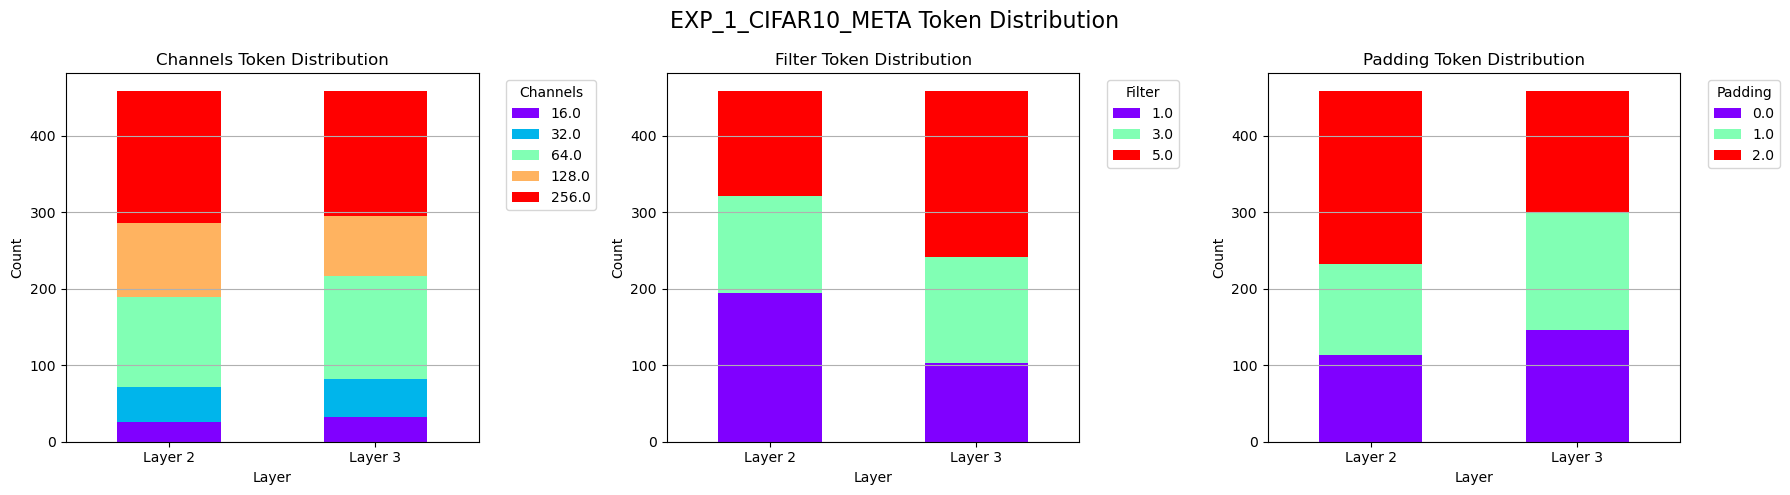

In [49]:
analysis.compare_metrics([df_exp3, df_exp1_meta], df_names=["EXP_3_CIFAR10", "EXP_1_CIFAR10_META"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300)

analysis.plot_token_distribution(df_exp3, "EXP_3_CIFAR10", include_layer1=False, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp1_meta, "EXP_1_CIFAR10_META", include_layer1=False, use_sns=True, sns_palette="rainbow")

In [50]:
print("EXP_3_CIFAR10 Statistics:")
analysis.compute_stats(df_exp3, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"], limit=300)

EXP_3_CIFAR10 Statistics:


test_acc                   total_param_count                          
                 mean       std     max              mean            std        max
range_label                                                                        
0-49         0.754944  0.033403  0.8052         257446.08  333695.990996  1642368.0
50-99        0.765864  0.029342  0.8052         280324.16  344293.764144  1937408.0
100-149      0.766268  0.026724  0.8121         243500.80  204145.457226   970624.0
150-199      0.759716  0.025922  0.8052         178565.76  163040.337386   823040.0
200-249      0.758964  0.026249  0.8151         173442.88  139262.848498   618176.0
250-299      0.768060  0.023425  0.8022         158457.92  103742.291536   618176.0

In [59]:
print("EXP_1_CIFAR10_META Statistics:")
analysis.compute_stats(df_exp1_meta, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"], limit=300)

EXP_1_CIFAR10_META Statistics:


test_acc                   total_param_count                          
                 mean       std     max              mean            std        max
range_label                                                                        
0-49         0.758784  0.033926  0.8073         381875.52  505488.499328  2461696.0
50-99        0.765034  0.030604  0.8128         282540.80  315669.890530  1675264.0
100-149      0.772240  0.028459  0.8145         552388.48  617076.801951  2461696.0
150-199      0.774952  0.023871  0.8080         419198.08  519226.033403  2461696.0
200-249      0.778472  0.018890  0.8164         582030.72  592173.660114  2461696.0
250-299      0.773830  0.030198  0.8141         364602.88  373854.084362  1937408.0

##### 3.4. Result Analysis

We refer to the controller with the modified reward function as Experiment 3 controller and the original controller from Experiment 1 as the Experiment 1 controller.

From the test accuracy graph we can observe that the variance increased for the Experiment 3 controller as compared to the Experiment 1 controller. Similarly, from the max accuracy graph we can also observe that Experiment 3 controller seems to lag a bit behind the Experiment 1 controller which is to be expected as we are introducing a penalty based on the model complexity.

However, a more interesting trend can be observed in the total parameter count graph where it is clearly visible that the controller started to favour lower complexity models as compared to the original one. Experiment 3 controller is still able to exhibit comparable test accuracies to the Experiment 1 controller. The token distribution graph complements this observation as it shows the Experiment 3 controller leaning more towards smaller channel, filter and padding sizes as compared to the Experiment 1 controller.

This increase in model efficiency comes at the slight cost of performance but not by a large amount. The mean accuracy in the last interval 250-299 for the modified reward function controller was 76.8% while its mean parameter count was 618,176. The Experiment 1 controller, meanwhile, had a mean test accuracy of 77.3% and a mean total parameter count of 1,937,408. This indicates that with a suitable reward function the controller can learn architectures while optimizing multiple objectives.

#### Experiment 4 - If the Controller is pre-trained on one dataset, can it adapt more quickly when applied to a similar dataset?

**Transfer Learning CIFAR10 - 100**

##### 4.1. Approach
In our previous experiments, we trained the controller on each dataset, allowing it to learn architectural preferences through reinforcement learning entirely from that dataset's feedback. We now wanted to explore whether pre-training the controller on one dataset could enable faster adaptation when applied to a similar dataset.
The idea behind this is that if the controller has already learned useful model architectures — such as preferred filter sizes, kernel sizes, and padding strategies — from one dataset, it may not need to re-learn these  when applied to another, similar dataset. Instead, it could focus on fine-tuning the model architecture based on the new data.#### First we train a fresh controller on CIFAR-100

##### 4.2. Experiment setup

In this experiment, we aim to evaluate whether a pre-trained controller can adapt more quickly to a new dataset compared to a controller trained from scratch. To do this, we follow these three steps:
1. Train a new controller from scratch on CIFAR-100 (Fresh controller).
2. Train a controller on CIFAR-10
3. .Fine-tune the same controller on CIFAR-100 (Pre-trained controller).

The second step has already been completed in experiment 1, where we trained a controller on CIFAR-10. We will reuse this pre-trained controller for the third step.

Datasets used: CIFAR-10, CIFAR-100

In [52]:
experiment_name = "EXP_4_CIFAR_100_Fresh"

In [22]:
run_experiment(
    experiment_name,
    dataset_name="cifar100",
    model_iters=5,
    train_epochs=10,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=3,
    reset_experiment=False,
    use_metadata=True,
)

CIFAR-100 dataset missing - downloading...


100.0%


Extracting ../../data/cifar100/temp\cifar-100-python.tar.gz to ../../data/cifar100/temp
Files already downloaded and verified
Image size: 32
Number of channels: 3
Number of classes:  100
Controller will be saved to:  Models\Controller\CNN\EXP_4_CIFAR_100_Fresh.pt
Best child model will be saved to:  Models\Child\CNN\EXP_4_CIFAR_100_Fresh.pt
Training results will be saved to:  Results\Controller\CNN\EXP_4_CIFAR_100_Fresh.csv

[ITER 0] Model encoding = [[[3, 16, 3, 1], [2, 2], [16, 32, 3, 0], [2, 2], [32, 256, 5, 2], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.0936382646560667	validation_loss: 2.135821645259857	test_acc: 0.4378	train_time: 60.57062840461731	policy_gradient: tensor([4.6348], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 16, 5, 2], [2, 2], [16, 16, 5, 0], [2, 2], [16, 128, 3, 0], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.594025581359863	validation_loss: 2.5261337471008303	test_acc: 0.3538	train_time: 60.443177461624146	policy

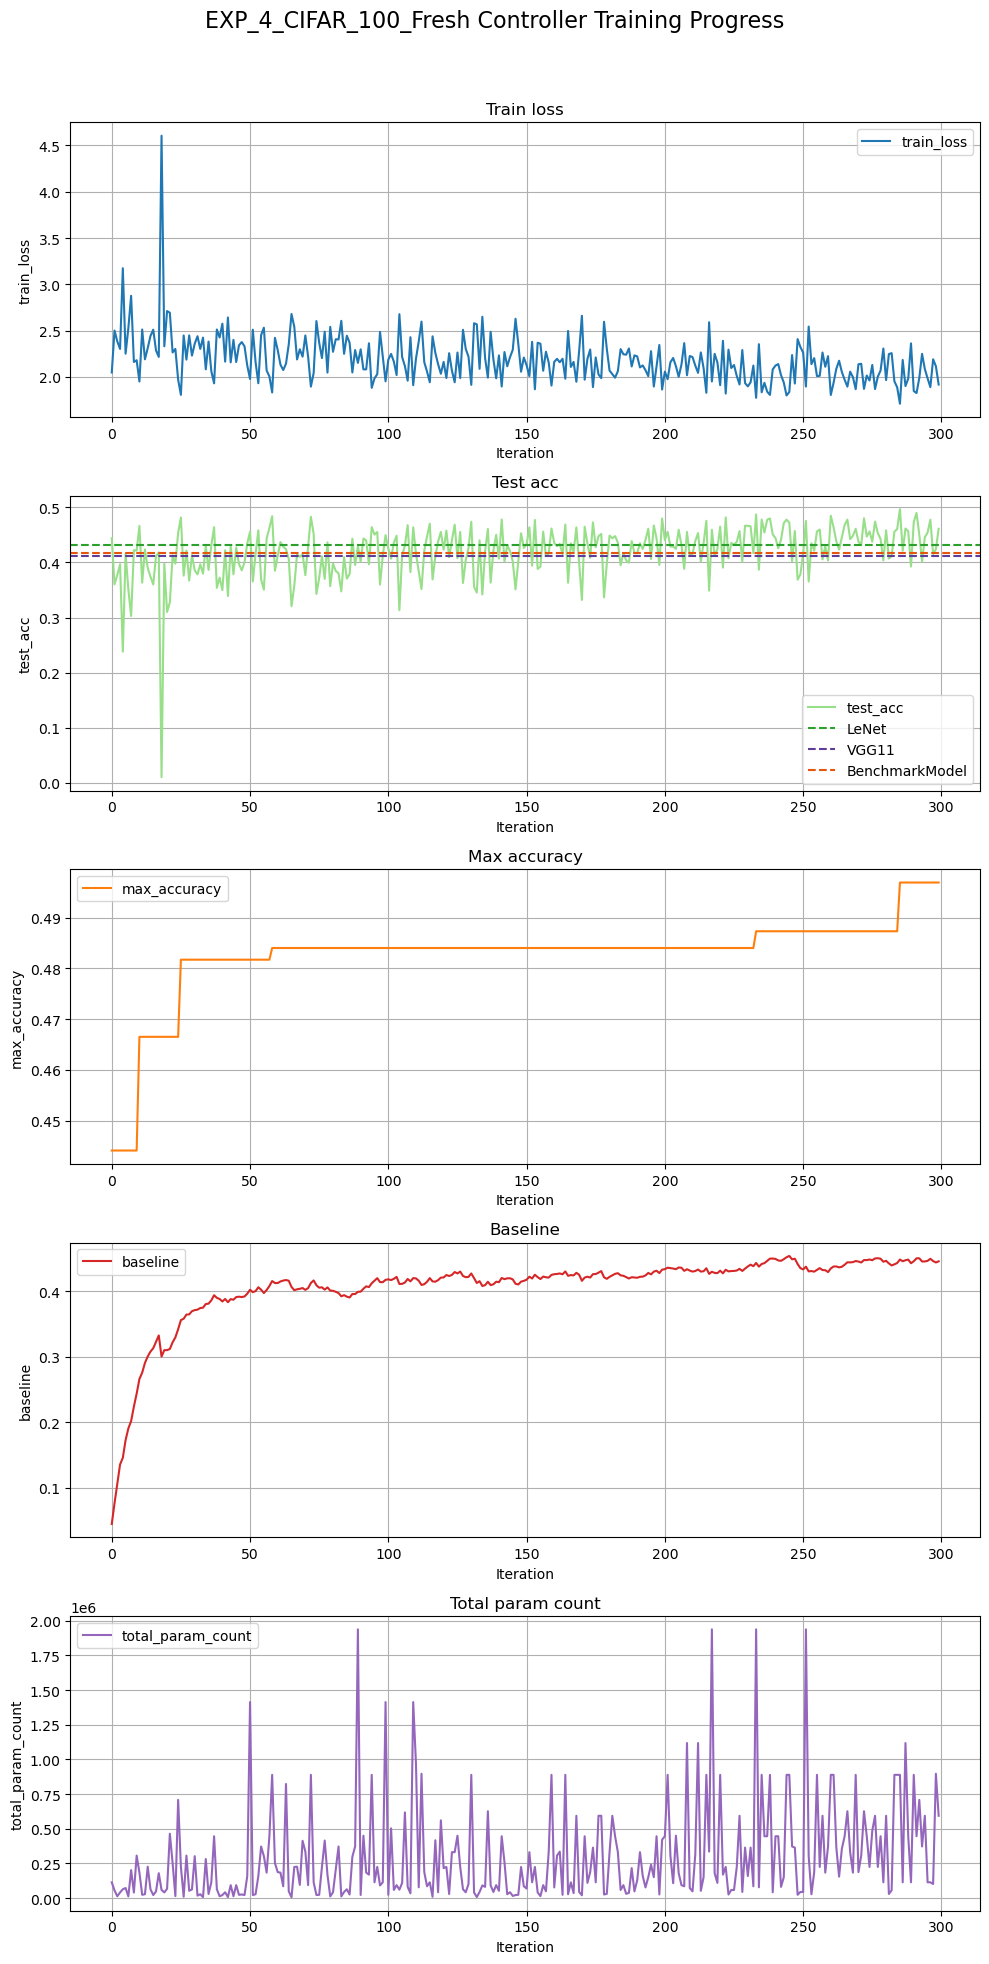

In [53]:
df_exp4_fresh = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp4_fresh, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300, colors=colors, references=references_cifar100) #Add benchmark

In [54]:
experiment_name = "EXP_4_CIFAR_100_Pre_Trained"

In [24]:
run_experiment(
    experiment_name,
    dataset_name="cifar100",
    model_iters=5,
    train_epochs=10,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=3,
    reset_experiment=False,
    use_metadata=True,
)

Image size: 32
Number of channels: 3
Number of classes:  100
Controller will be saved to:  Models\Controller\CNN\EXP_4_CIFAR_100_Pre_Trained.pt
Best child model will be saved to:  Models\Child\CNN\EXP_4_CIFAR_100_Pre_Trained.pt
Training results will be saved to:  Results\Controller\CNN\EXP_4_CIFAR_100_Pre_Trained.csv

[ITER 0] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 128, 5, 2], [2, 2], [128, 16, 5, 2], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.287322114944458	validation_loss: 2.294109489917755	test_acc: 0.3982	train_time: 74.96986651420593	policy_gradient: tensor([4.5082], grad_fn=<MulBackward0>)

[ITER 1] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 16, 3, 1], [2, 2], [16, 32, 1, 2], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.4543497514724733	validation_loss: 2.452802610397339	test_acc: 0.3655	train_time: 65.92365145683289	policy_gradient: tensor([3.8217], grad_fn=<MulBackward0>)

[ITER 2] Model encoding = [[[3, 128, 3, 1], [2, 2], [

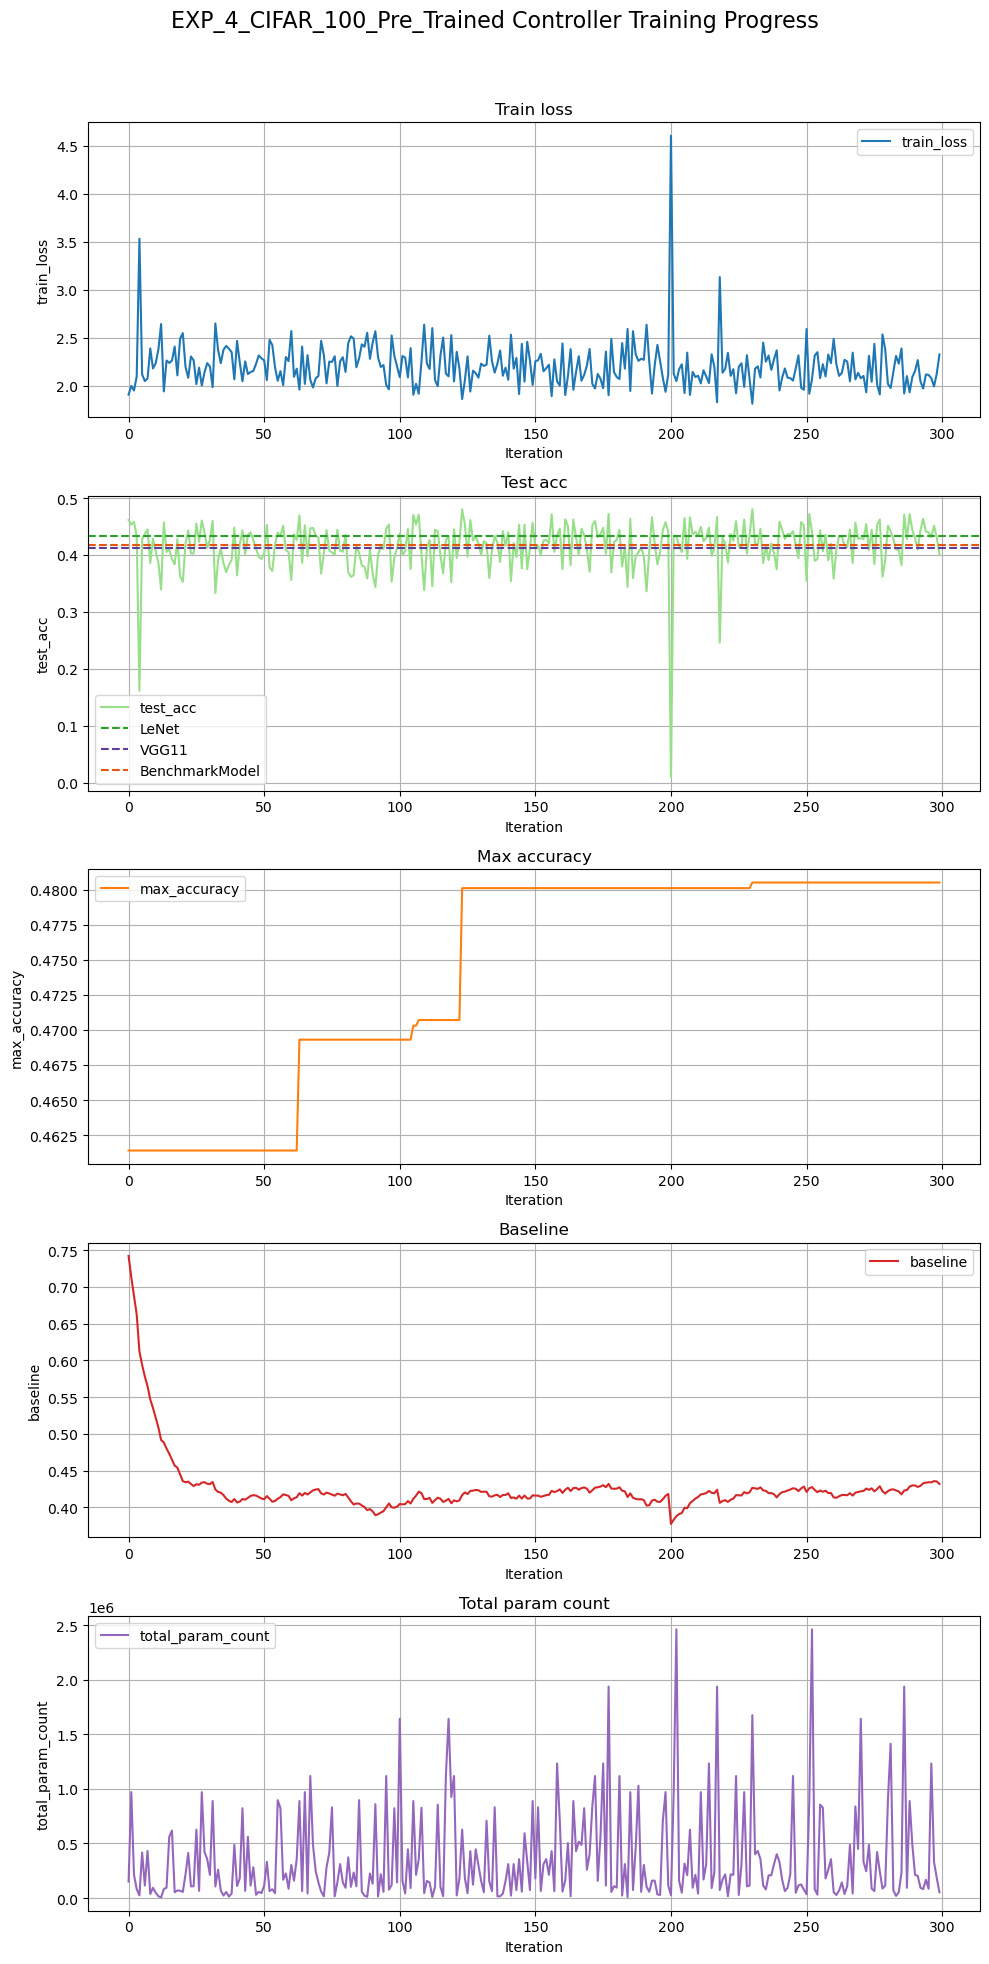

In [60]:
df_exp4_trained = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp4_trained, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300, colors=colors, references=references_cifar100) #Add benchmark

##### 4.3. Now lets compare the results of the fresh model and pre-trained model

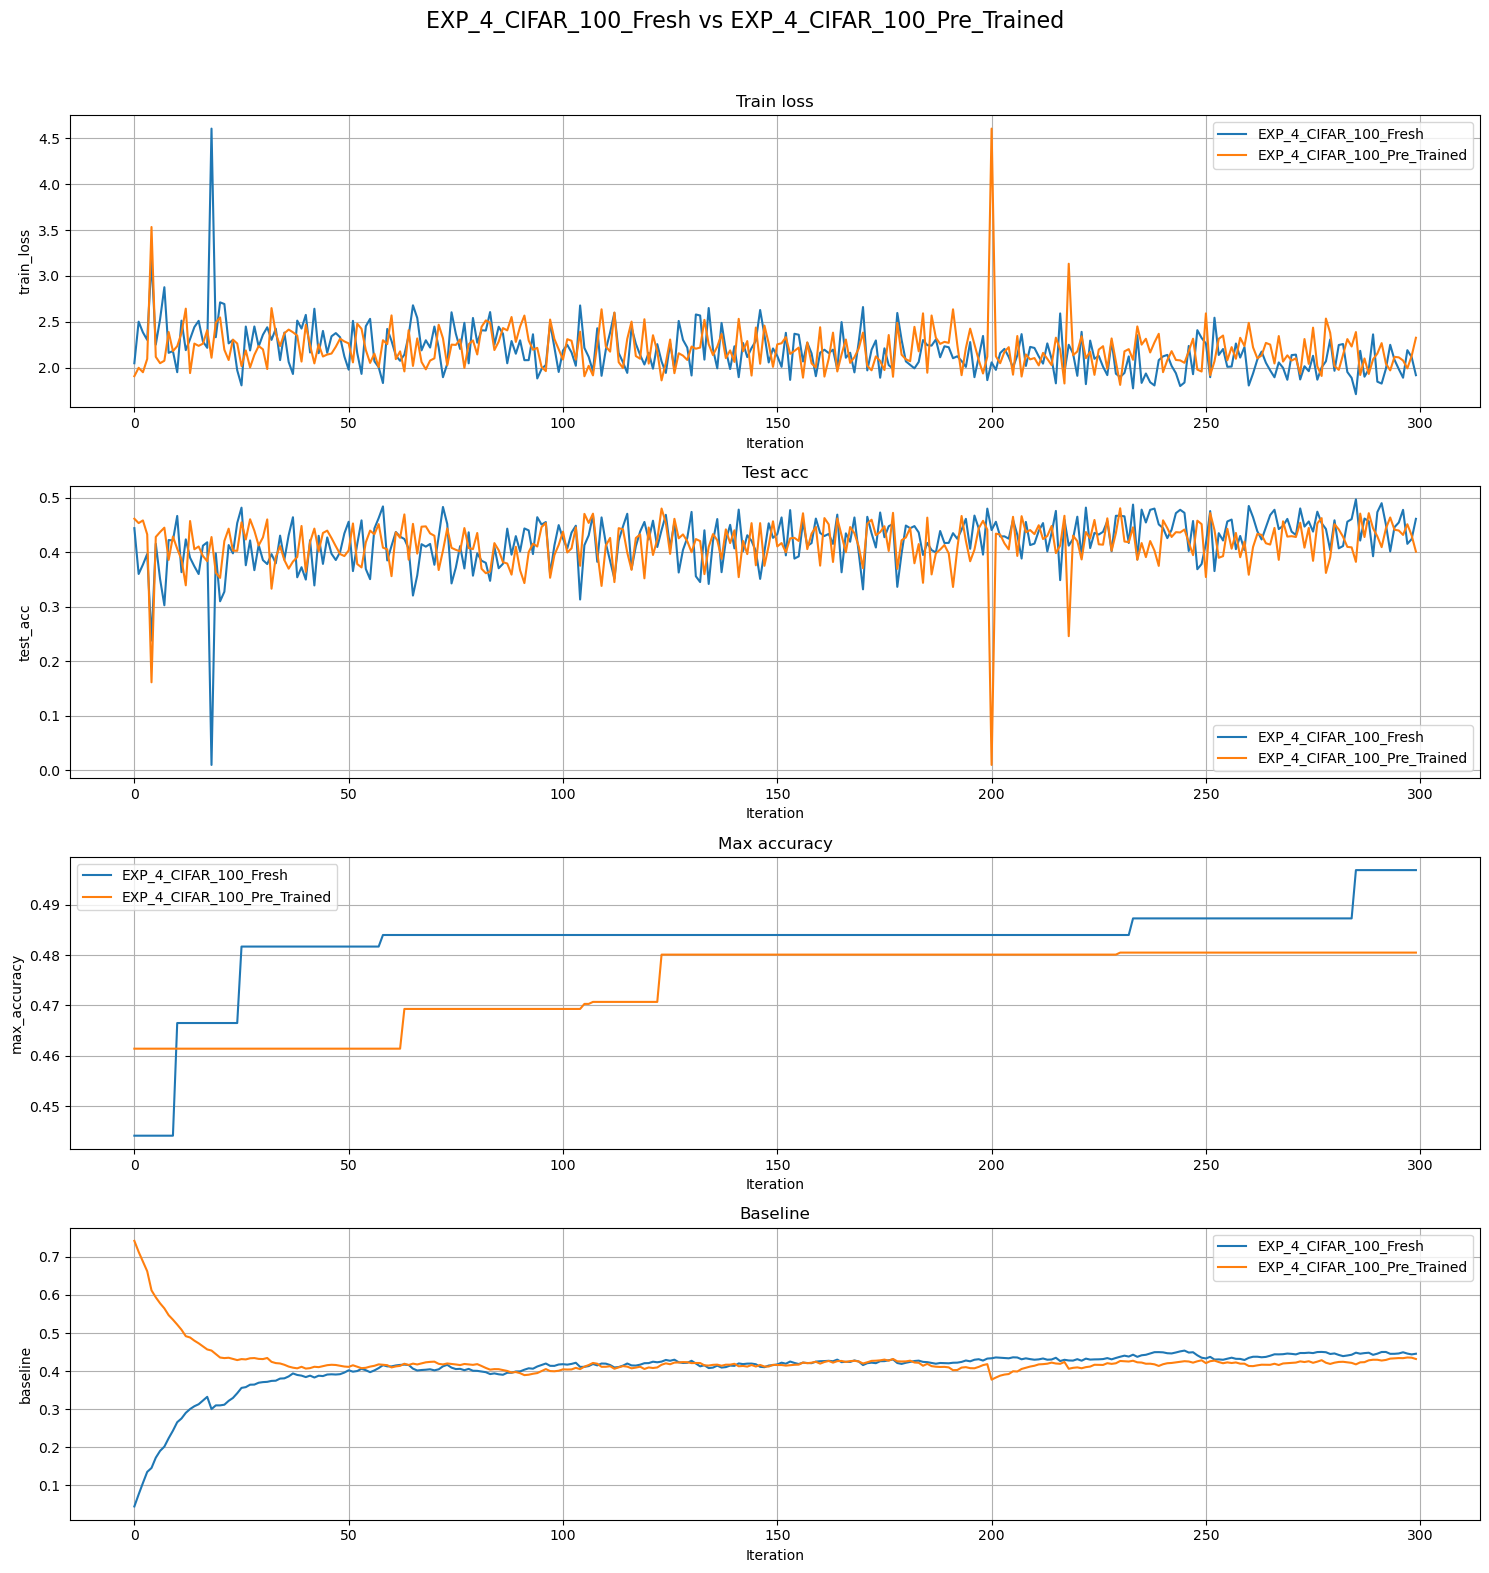

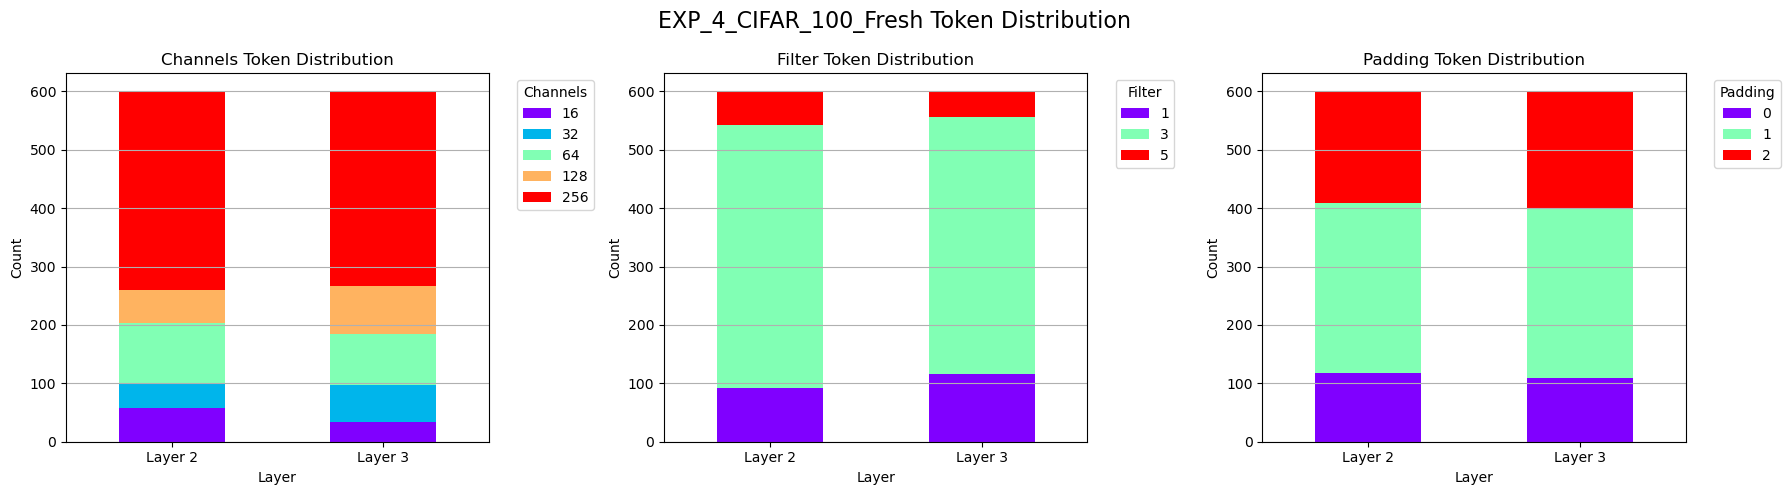

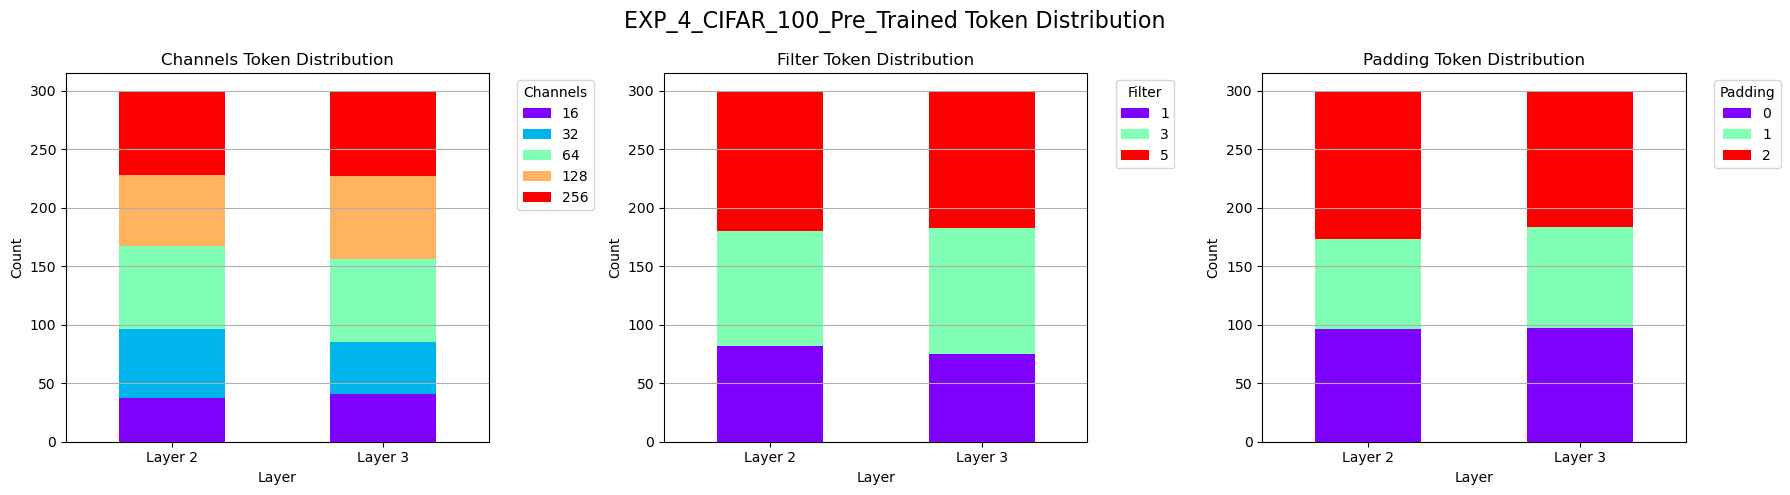

In [61]:
analysis.compare_metrics([df_exp4_fresh, df_exp4_trained], df_names=["EXP_4_CIFAR_100_Fresh", "EXP_4_CIFAR_100_Pre_Trained"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300)

analysis.plot_token_distribution(df_exp4_fresh, "EXP_4_CIFAR_100_Fresh", include_layer1=False, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp4_trained, "EXP_4_CIFAR_100_Pre_Trained", include_layer1=False, use_sns=True, sns_palette="rainbow")

##### 4.4. Token distribution Analysis

Comparing the token distributions between the fresh and pre-trained controllers on CIFAR-100 shows clear differences in architectural choices. The fresh controller seems to heavily favor larger channel sizes, with 256 filters dominating, while the pre-trained controller  shows a more balanced spread across 32, 64, and 128 filters.

For kernel size, both controllers prefer 3x3, but the pre-trained controller exhibits a slightly higher use of 5x5 kernels, likely due to pre-existing biases from its earlier CIFAR-10 training. Padding choices show that the fresh controller consistently uses padding 1 and 2 to preserve spatial dimensions, while the pre-trained controller employs a slightly more varied strategy, including more frequent use of padding 0.

Overall, while the fresh controller trends toward larger, more complex architectures, the pre-trained controller generates more balanced models, indicating that prior experience could have influenced its search behavior even while training with a different dataset

In [62]:
print("EXP_4_CIFAR_100_Fresh Statistics:")
analysis.compute_stats(df_exp4_fresh, metrics=["test_acc", "baseline",], stats=["mean", "std", "max"],limit=300)

EXP_4_CIFAR_100_Fresh Statistics:


test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.384996  0.069863  0.4817  0.313690  0.091956  0.396143
50-99        0.409148  0.039415  0.4840  0.405341  0.007652  0.419838
100-149      0.417080  0.039468  0.4781  0.417365  0.005449  0.429911
150-199      0.427028  0.032904  0.4799  0.423944  0.003737  0.432845
200-249      0.437476  0.032638  0.4873  0.437066  0.007584  0.453800
250-299      0.444092  0.027933  0.4969  0.442215  0.006310  0.450310

In [63]:
print("EXP_4_CIFAR_100_Pre_Trained Statistics:")
analysis.compute_stats(df_exp4_trained, metrics=["test_acc", "baseline"], stats=["mean", "std", "max"],limit=300)

EXP_4_CIFAR_100_Pre_Trained Statistics:


test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.408106  0.048053  0.4614  0.473143  0.086184  0.742075
50-99        0.408186  0.031791  0.4693  0.410177  0.009474  0.424774
100-149      0.416666  0.034466  0.4801  0.413868  0.005411  0.423630
150-199      0.419690  0.033153  0.4722  0.419366  0.007396  0.431847
200-249      0.416368  0.068333  0.4805  0.414557  0.011854  0.428288
250-299      0.424380  0.029251  0.4718  0.423751  0.005749  0.435677

##### 4.5. Result Analysis
Studying the results reveals some interesting trends. In the first 50 iterations, the pre-trained controller achieves a higher mean test accuracy than the freshly initialized one (0.408 vs 0.384), suggesting that its prior training gives it a  head start. However, as the search progresses, the fresh controller steadily closes the gap and eventually surpasses the pre-trained model. In the final 50 iterations (250–299), the fresh controller achieves both a higher mean accuracy (0.444 vs 0.424) and a higher maximum accuracy (0.496 vs 0.471).

The baseline trend, seems to explain the above behaviour. The pre-trained controller begins with a really high baseline, not due to better performance on CIFAR-100, but because it retains traces of the reward from its earlier training on CIFAR-10 — a dataset on which a 3 layer CNN model can achieve a much higher accuracy. As training continues on CIFAR-100, the baseline adjusts downward, eventually aligning with the baseline of the fresh controller around iteration 100. This could suggest that the in the first 100 iterations the pre-trained model was mostly adapting to the new baseline accuracy which is much lower than the data it had previously trained on. This could be the reason it's accuracy doesn't significantly increase on those iterations.

The pre-trained controller exhibits lower variance in test accuracy early on, reflecting its existing policy initialization. However, by later stages, both controllers converge to similar levels of variance. Interestingly, while the pre-trained controller plateaus in max accuracy around iteration 150, the fresh controller continues to improve gradually throughout the 300 iterations. This suggests that while pre-training gives a head start in early learning, it may also constrain further exploration, potentially causing the controller to settle prematurely in a suboptimal region of the possible architecture space. In contrast, the fresh controller’s slower start allows for more flexible adaptation, ultimately leading to better peak performance.



## Generated Model architecture evaluation

To evaluate the quality of architectures generated by our NAS controller, we compared the best models from each  experiment against standard benchmarks on CIFAR-10 and CIFAR-100 datasets. The benchmark models include LeNet, VGG-11, and the unmodified custom benchmark model (the base model for the experiments) designed for each dataset.

### CIFAR-10 Benchmark Table

| Model                  | 10 Epochs | 20 Epochs | 30 Epochs |
|:-----------------------|----------:|----------:|----------:|
| LeNet                  |    0.7545 |    0.7765 |    0.8185 |
| VGG_11                 |    0.7811 |    0.8245 |    0.8346 |
| Custom Benchmark_Model |    0.7738 |    0.8095 |    0.8167 |
| EXP_1_CIFAR10_NO_META  |    0.7938 |    0.8223 |    0.8409 |
| EXP_1_CIFAR10_META     |    0.8164 |    0.8330 |    0.8503 |
| EXP_6_CIFAR10          |    0.7929 |    0.8317 |    0.8233 |
| Exp_5_3_Layer_CIFAR_10 |    0.7371 |    0.7631 |    0.7867 |

On CIFAR-10, the best architectures generated by the controller consistently outperformed LeNet and in some cases even surpassed VGG-11 performance. Interestingly, EXP_1_CIFAR10_META achieved the highest performance among all tested models, reaching a test accuracy of 85.03% after 30 epochs, outperforming both LeNet (81.85%) and VGG-11 (83.46%). This demonstrates the controller's ability to generate architectures that can rival human-created models in lesser number of epochs.

### CIFAR-100 Benchmark Table

| Model                      | 10 Epochs | 20 Epochs | 30 Epochs |
|:---------------------------|----------:|----------:|----------:|
| LeNet                      |    0.4326 |    0.4566 |    0.4967 |
| VGG_11                     |    0.4114 |    0.4686 |    0.4750 |
| Custom Benchmark_Model     |    0.4172 |    0.4573 |    0.4992 |
| EXP4_CIFAR_100_Fresh       |    0.4791 |    0.5229 |    0.5317 |
| EXP4_CIFAR_100_Pre_Trained |    0.4981 |    0.5136 |    0.5299 |

On CIFAR-100, the trend was similar. The architectures discovered by the controller, particularly EXP4_CIFAR_100_Fresh and EXP4_CIFAR_100_Pre_Trained, outperformed standard baselines. After 30 epochs, EXP4_CIFAR_100_Fresh achieved 53.17% accuracy, significantly outperforming LeNet (49.67%) and VGG-11 (47.50%) even in this more challenging task.

Overall, these results seem to suggest that the architectures discovered through NAS are competitive with, and sometimes superior to, traditionally designed models even when trained for a lesser number of epochs. They also illustrate the benefit of targeted architecture search — models generated for a specific dataset consistently outperformed generic baselines.

## Conclusion

In this project, we explored Neural Architecture Search (NAS) using a reinforcement learning-based controller to generate CNN architectures for image classification. Through experiments on CIFAR-10 and CIFAR-100, we found that:
- Providing dataset-specific metadata improved controller performance.
- Expanding the controller's search space to generate more layers increased variability but ultimately produced comparable models.
- Rewarding parameter efficiency allowed the controller to discover more compact yet accurate architectures.
- Pre-training on one dataset helped initial learning but limited long-term exploration flexibility.

NAS-generated models often outperformed traditional baselines like LeNet and VGG-11, demonstrating that even with simple setups and modest compute, NAS can uncover efficient, high-performing architectures. Future work could involve expanding the search space or incorporating hardware constraints to further optimize model discovery.